
LOADING DATASET: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv

✅ Dataset loaded successfully!
   Shape: (449, 21)
   Columns: 21
   Rows: 449

1. BASIC DATASET INFORMATION

Dataset Preview (First 5 rows):
   wmc  dit  noc  cbo  rfc  lcom  ca  ce  npm     lcom3  ...       dam  moa  \
0    4    4    0    3   12     6   2   1    4  2.000000  ...  0.000000    0   
1    2    1    0    0    3     1   0   0    2  2.000000  ...  0.000000    0   
2    8    1    0    6   22     0   3   3    8  0.142857  ...  1.000000    0   
3    8    2    1    7   24    12   1   6    8  0.936508  ...  0.555556    0   
4   10    1    5   34   13    45  32   2    9  1.000000  ...  0.000000    0   

        mfa       cam  ic  cbm     amc  max_cc  avg_cc  bug  
0  0.953488  0.357143   1    3  23.750       3   1.000    0  
1  0.000000  0.500000   0    0   2.000       1   0.500    0  
2  0.000000  0.406250   0    0  20.875       5   3.125    0  
3  0.533333  0.333333   0    0  20.250       7   2.250    0 

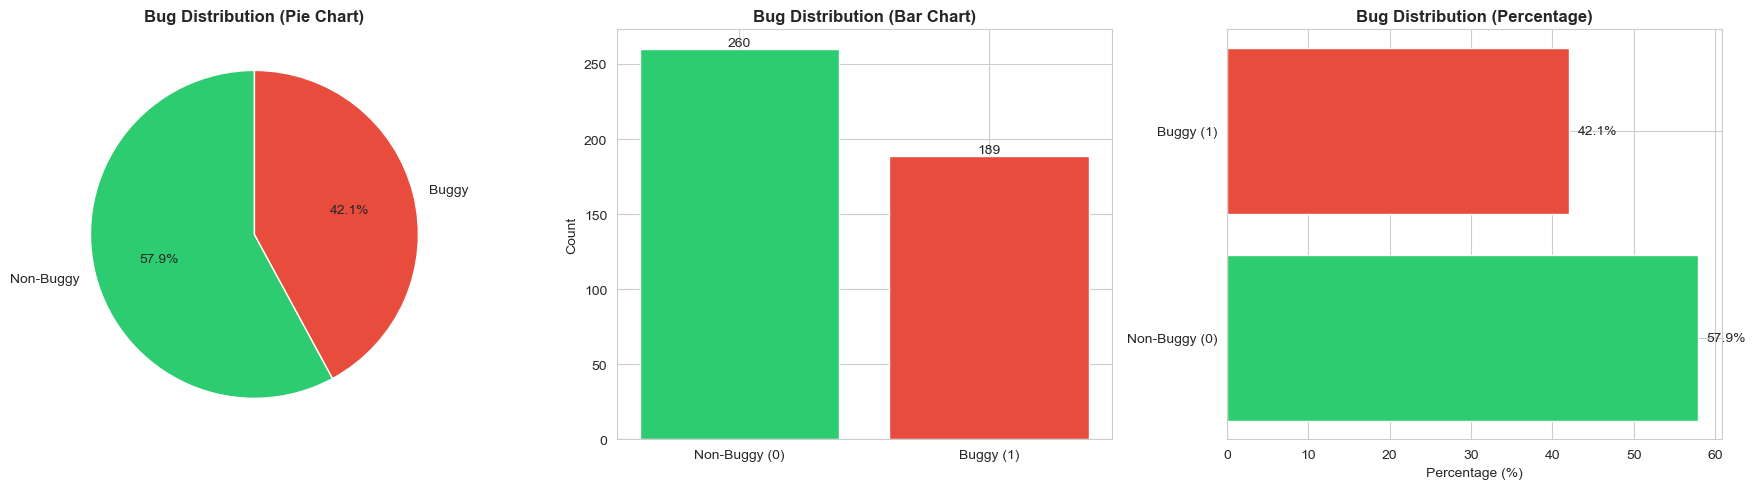


4. OUTLIER DETECTION & NOISE ANALYSIS

Outlier Summary (Top 10 columns):
Column  IQR_Outliers  IQR_Percentage  Z_Score_Outliers  Z_Score_Percentage
    ca            64       14.253898                15            3.340757
  lcom            62       13.808463                 2            0.445434
   cbo            48       10.690423                12            2.672606
   cbm            48       10.690423                 7            1.559020
   noc            44        9.799555                10            2.227171
   moa            39        8.685969                 6            1.336303
   dit            33        7.349666                 9            2.004454
   cam            30        6.681514                 0            0.000000
   npm            26        5.790646                 8            1.781737
   wmc            25        5.567929                 4            0.890869


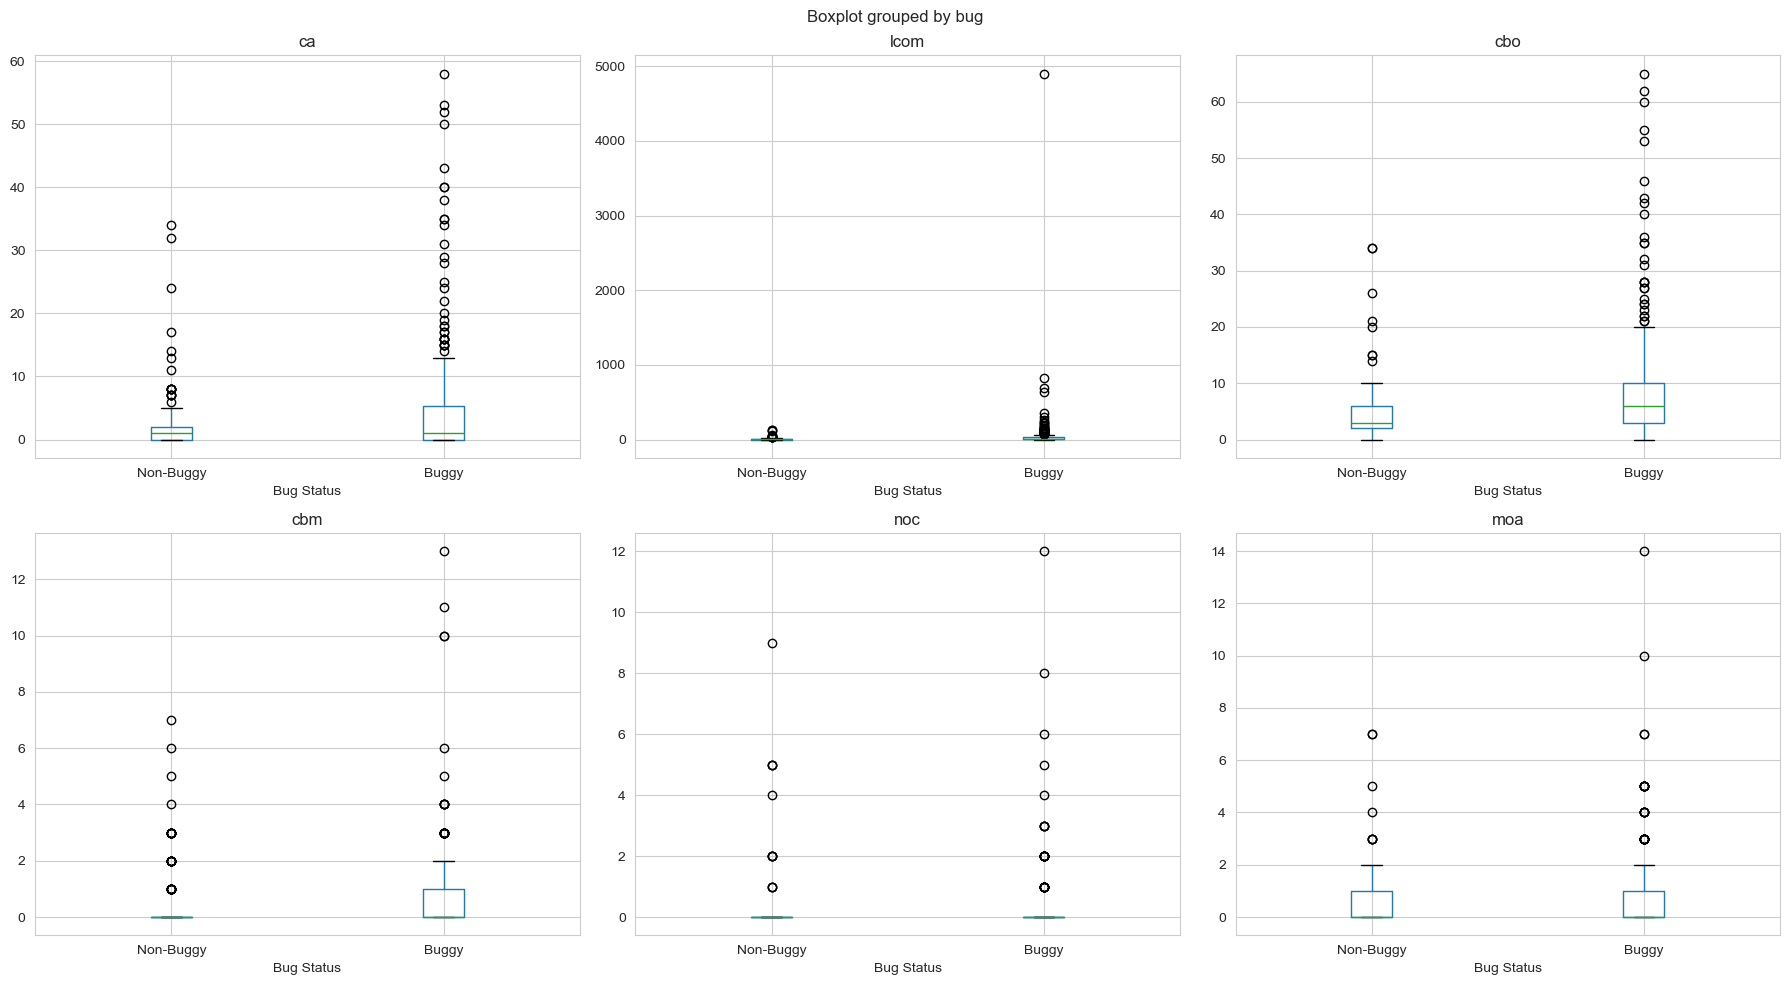


⚠️  4 columns have >10% outliers:
   ['ca', 'lcom', 'cbo', 'cbm']

💡 Recommendations:
   • Consider log transformation or winsorization
   • Check if outliers are data errors or genuine extreme values
   • Robust scaling may help (RobustScaler)

5. CORRELATION ANALYSIS

Top 10 Features Correlated with Bug:
npm       0.298001
wmc       0.283924
cbo       0.268244
dam       0.267039
rfc       0.256627
ce        0.236627
loc       0.230993
ca        0.202211
max_cc    0.190880
moa       0.145153
Name: bug, dtype: float64


Multicollinearity Detection (|correlation| > 0.8):
────────────────────────────────────────────────────────────
Feature_1 Feature_2  Correlation
      cbo        ca     0.940522
      rfc       loc     0.906172
   max_cc    avg_cc     0.889517
      wmc       rfc     0.876113
      rfc        ce     0.844624
      dit       mfa     0.833604
      wmc       npm     0.815476

⚠️  Found 7 highly correlated feature pairs
💡  Consider removing redundant features or using PCA

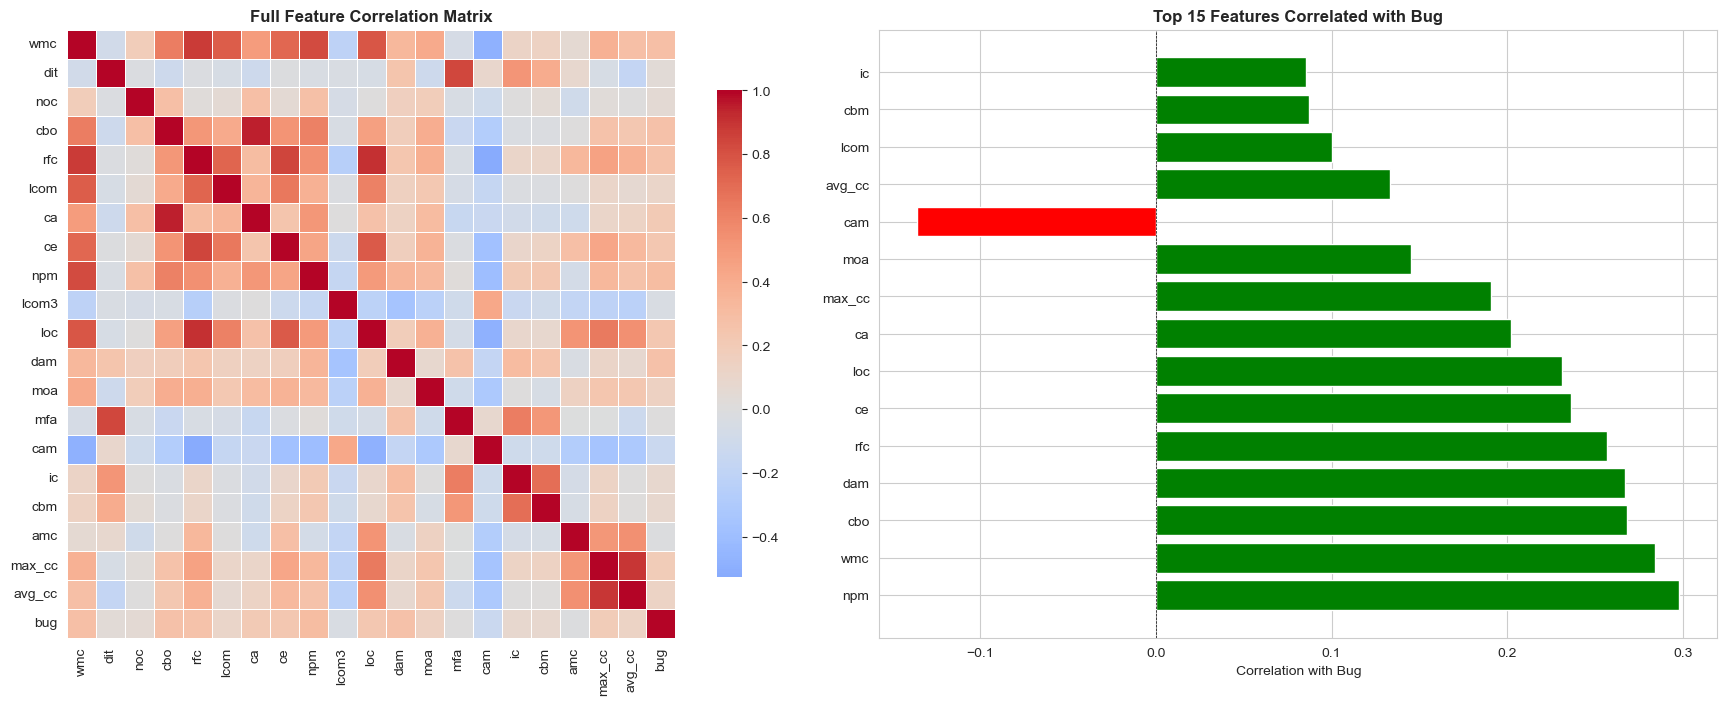


6. FEATURE DISTRIBUTION ANALYSIS

Normality Test Results (Shapiro-Wilk, p > 0.05 = Normal):
────────────────────────────────────────────────────────────
Feature  Statistic      P-Value Normal
    cam   0.910094 1.150099e-15     No
 avg_cc   0.871436 8.205662e-19     No
    amc   0.841162 8.055815e-21     No
  lcom3   0.837608 4.893118e-21     No
 max_cc   0.729587 2.328244e-26     No
     ce   0.709199 3.598854e-27     No
    npm   0.706969 2.952459e-27     No
    mfa   0.699393 1.520168e-27     No
    loc   0.681916 3.450312e-28     No
    rfc   0.681068 3.216139e-28     No

📊 20/20 features are non-normal
💡 Consider transformation (log, sqrt, box-cox) for non-normal features


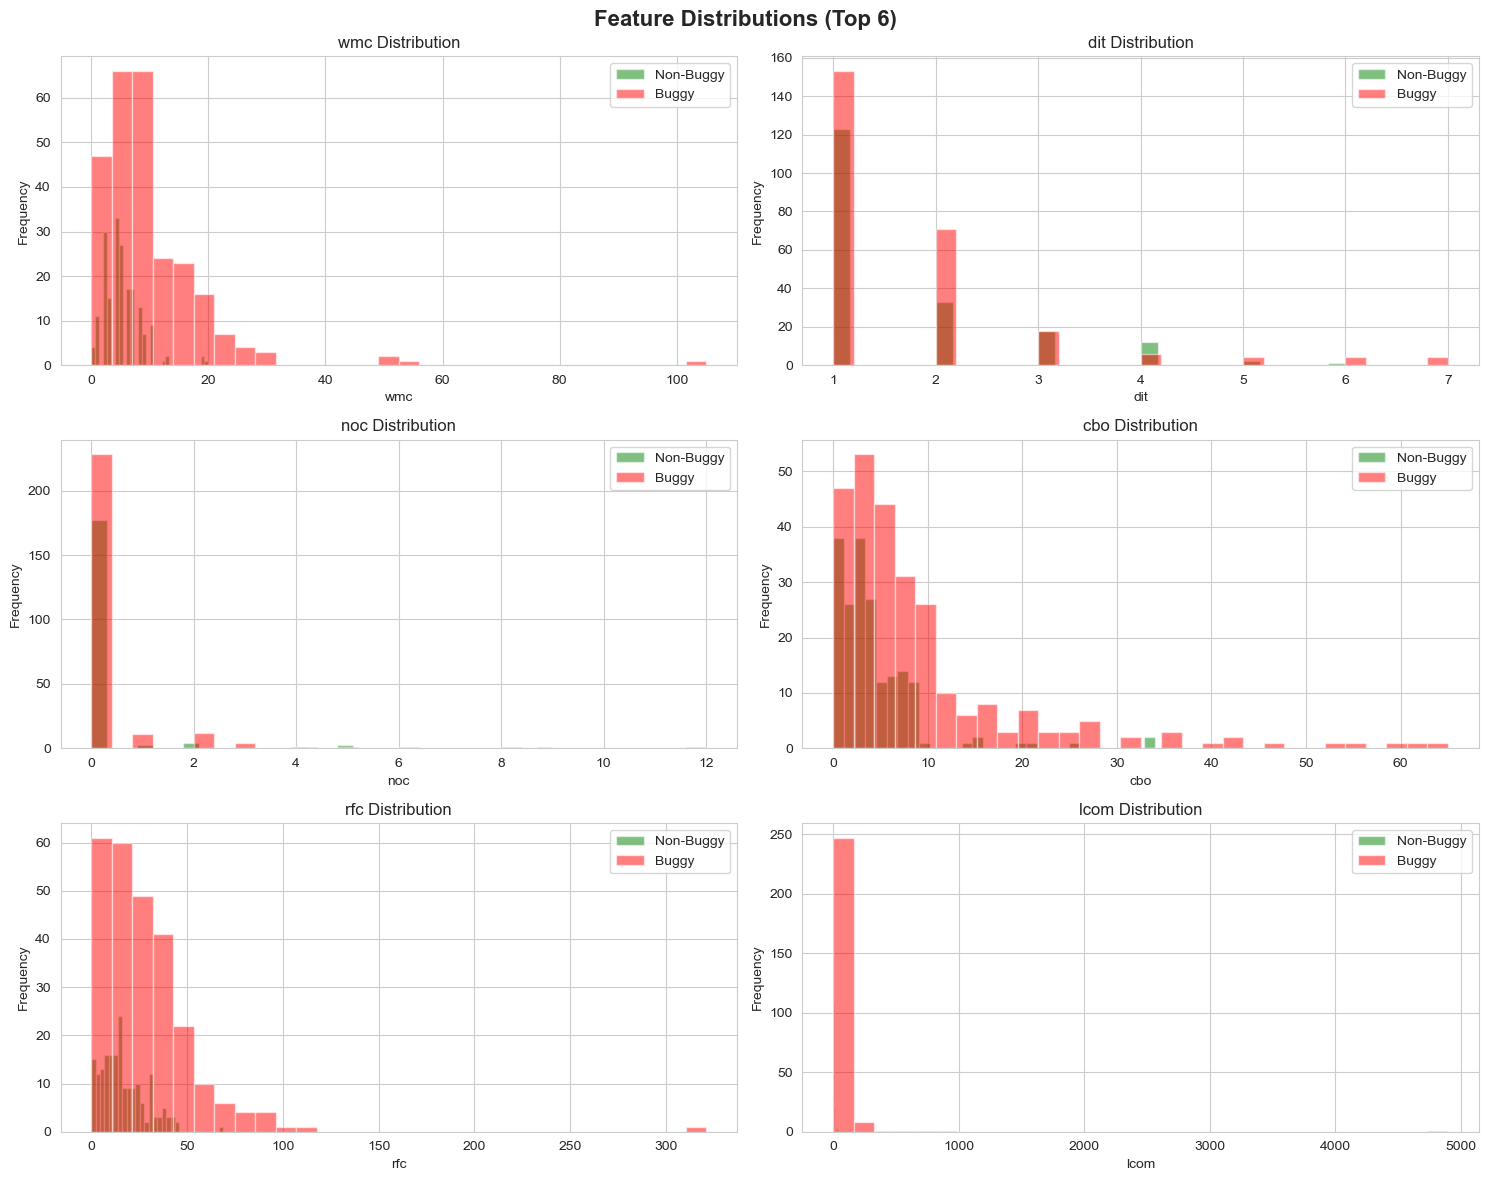


7. DIMENSIONALITY REDUCTION & VISUALIZATION

PCA Analysis:
  • Components needed for 95% variance: 12/20
  • Variance explained by first 10 components: 91.1%


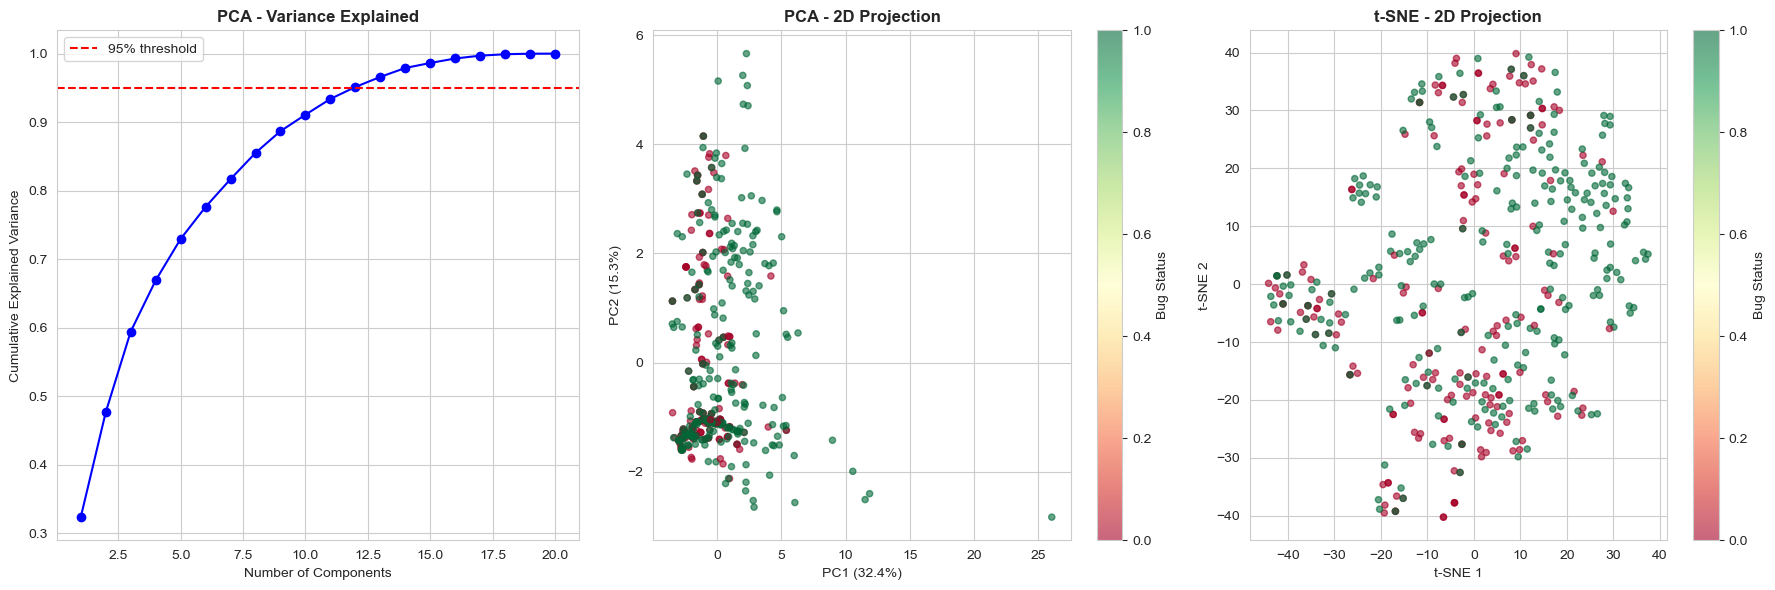


💡 Insights:
   • Data is spread across many dimensions (complex dataset)
   • Check t-SNE plot: clear clusters = good separability

8. FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
Feature  Importance
    cbo    0.096692
    loc    0.086711
    amc    0.077861
    wmc    0.076344
    rfc    0.073407
    dam    0.067667
    npm    0.063823
     ca    0.061491
   lcom    0.057965
    cam    0.054849
  lcom3    0.052241
 avg_cc    0.048523
     ce    0.048365
    mfa    0.032112
 max_cc    0.029658
    dit    0.020325
    cbm    0.016519
    moa    0.016425
    noc    0.012008
     ic    0.007014


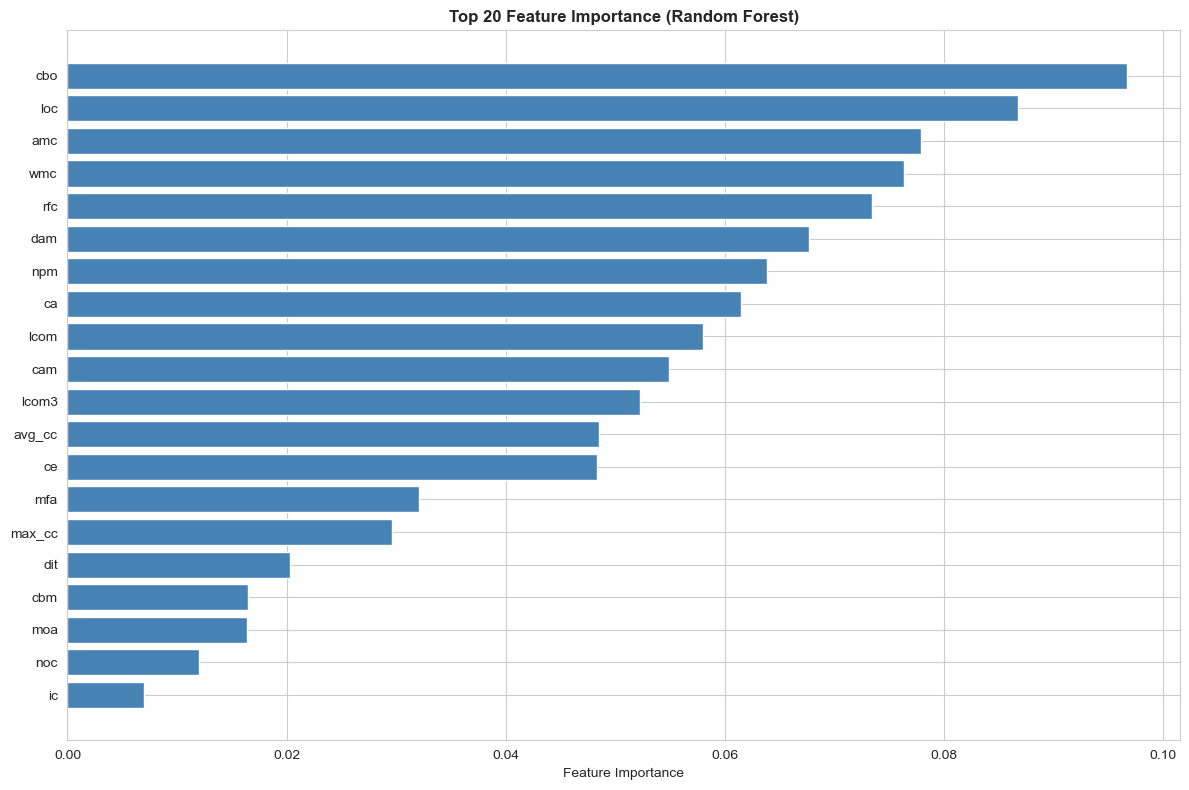


💡 Insight: Top 12 features explain 80% of importance
   Consider feature selection to reduce dimensionality

9. COMPREHENSIVE SUMMARY REPORT

DATASET OVERVIEW
File: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv
Total Rows: 449
Total Features: 20
Missing Data: 0 cells

────────────────────────────────────────────────────────────
CLASS DISTRIBUTION
────────────────────────────────────────────────────────────
Non-Buggy (0): 189 (42.1%)
Buggy (1): 260 (57.9%)
Imbalance Ratio: 1.38:1

────────────────────────────────────────────────────────────
DATA QUALITY ISSUES
────────────────────────────────────────────────────────────
✅ No missing values

────────────────────────────────────────────────────────────
RECOMMENDATIONS
────────────────────────────────────────────────────────────
• Apply feature scaling (StandardScaler or RobustScaler)
• Consider feature selection to reduce dimensionality
• Monitor for overfitting with cross-validation


UnicodeEncodeError: 'charmap' codec can't encode characters in position 267-326: character maps to <undefined>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, shapiro, normaltest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


class BugDatasetAnalyzer:
    """
    Comprehensive Exploratory Data Analysis for Bug Classification Datasets
    """
    
    def __init__(self, file_path, target_column='bug'):
        """
        Initialize the analyzer with dataset path
        
        Parameters:
        -----------
        file_path : str
            Path to the CSV file
        target_column : str
            Name of the target column (default: 'bug')
        """
        self.file_path = file_path
        self.target_column = target_column
        self.df = None
        self.df_processed = None
        self.features = None
        
        print(f"\n{'='*80}")
        print(f"LOADING DATASET: {file_path}")
        print(f"{'='*80}\n")
        
        self._load_data()
    
    def _load_data(self):
        """Load and perform initial preprocessing"""
        self.df = pd.read_csv(self.file_path)
        print(f"✅ Dataset loaded successfully!")
        print(f"   Shape: {self.df.shape}")
        print(f"   Columns: {self.df.shape[1]}")
        print(f"   Rows: {self.df.shape[0]}")
    
    def basic_info(self):
        """Display basic dataset information"""
        print(f"\n{'='*80}")
        print("1. BASIC DATASET INFORMATION")
        print(f"{'='*80}\n")
        
        print("Dataset Preview (First 5 rows):")
        print(self.df.head())
        
        print(f"\n\nDataset Info:")
        print(f"{'─'*60}")
        self.df.info()
        
        print(f"\n\nBasic Statistics:")
        print(f"{'─'*60}")
        print(self.df.describe())
        
        # Data types summary
        print(f"\n\nData Types Summary:")
        print(f"{'─'*60}")
        dtype_counts = self.df.dtypes.value_counts()
        for dtype, count in dtype_counts.items():
            print(f"  {dtype}: {count} columns")
    
    def missing_data_analysis(self):
        """Analyze missing data patterns"""
        print(f"\n{'='*80}")
        print("2. MISSING DATA ANALYSIS")
        print(f"{'='*80}\n")
        
        missing = self.df.isnull().sum()
        missing_pct = (missing / len(self.df)) * 100
        missing_df = pd.DataFrame({
            'Column': missing.index,
            'Missing_Count': missing.values,
            'Missing_Percentage': missing_pct.values
        })
        missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
        
        if len(missing_df) > 0:
            print(f"⚠️  Found {len(missing_df)} columns with missing values:\n")
            print(missing_df.to_string(index=False))
            
            # Visualize missing data
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            # Bar plot
            axes[0].barh(missing_df['Column'], missing_df['Missing_Percentage'], color='coral')
            axes[0].set_xlabel('Missing Percentage (%)')
            axes[0].set_title('Missing Data by Column', fontweight='bold')
            axes[0].invert_yaxis()
            
            # Heatmap
            sns.heatmap(self.df.isnull(), cbar=False, yticklabels=False, 
                       cmap='viridis', ax=axes[1])
            axes[1].set_title('Missing Data Pattern', fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            # Recommendation
            print(f"\n💡 Recommendation:")
            high_missing = missing_df[missing_df['Missing_Percentage'] > 50]
            if len(high_missing) > 0:
                print(f"   • Consider dropping columns with >50% missing: {list(high_missing['Column'])}")
            print(f"   • For others, consider imputation strategies (mean, median, mode)")
        else:
            print("✅ No missing data found!")
    
    def target_analysis(self):
        """Analyze target variable distribution"""
        print(f"\n{'='*80}")
        print("3. TARGET VARIABLE ANALYSIS (BUG CLASSIFICATION)")
        print(f"{'='*80}\n")
        
        # Process target: 0 = non-buggy, >0 = buggy
        print(f"Original '{self.target_column}' distribution:")
        print(self.df[self.target_column].value_counts().sort_index())
        
        # Binary classification
        self.df_processed = self.df.copy()
        self.df_processed[self.target_column] = self.df_processed[self.target_column].apply(
            lambda x: 0 if x == 0 else 1
        )
        
        print(f"\n\nBinary Classification Distribution:")
        print(f"{'─'*60}")
        class_counts = self.df_processed[self.target_column].value_counts()
        class_pct = (class_counts / len(self.df_processed)) * 100
        
        summary_df = pd.DataFrame({
            'Class': ['Non-Buggy (0)', 'Buggy (1)'],
            'Count': class_counts.values,
            'Percentage': class_pct.values
        })
        print(summary_df.to_string(index=False))
        
        # Calculate imbalance ratio
        imbalance_ratio = class_counts.max() / class_counts.min()
        print(f"\n📊 Imbalance Ratio: {imbalance_ratio:.2f}:1")
        
        if imbalance_ratio > 3:
            print(f"⚠️  HIGH CLASS IMBALANCE DETECTED!")
            print(f"   Recommendation: Use SMOTE, undersampling, or class weights")
        elif imbalance_ratio > 1.5:
            print(f"⚠️  Moderate class imbalance detected")
        else:
            print(f"✅ Classes are relatively balanced")
        
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Pie chart
        colors = ['#2ecc71', '#e74c3c']
        axes[0].pie(class_counts.values, labels=['Non-Buggy', 'Buggy'], 
                   autopct='%1.1f%%', colors=colors, startangle=90)
        axes[0].set_title('Bug Distribution (Pie Chart)', fontweight='bold')
        
        # Bar chart
        bars = axes[1].bar(['Non-Buggy (0)', 'Buggy (1)'], class_counts.values, color=colors)
        axes[1].set_ylabel('Count')
        axes[1].set_title('Bug Distribution (Bar Chart)', fontweight='bold')
        for bar in bars:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom')
        
        # Percentage bar
        axes[2].barh(['Non-Buggy (0)', 'Buggy (1)'], class_pct.values, color=colors)
        axes[2].set_xlabel('Percentage (%)')
        axes[2].set_title('Bug Distribution (Percentage)', fontweight='bold')
        for i, v in enumerate(class_pct.values):
            axes[2].text(v + 1, i, f'{v:.1f}%', va='center')
        
        plt.tight_layout()
        plt.show()
    
    def outlier_detection(self):
        """Detect outliers using IQR and Z-score methods"""
        print(f"\n{'='*80}")
        print("4. OUTLIER DETECTION & NOISE ANALYSIS")
        print(f"{'='*80}\n")
        
        # Get numeric columns only
        numeric_cols = self.df_processed.select_dtypes(include=[np.number]).columns.tolist()
        if self.target_column in numeric_cols:
            numeric_cols.remove(self.target_column)
        
        outlier_summary = []
        
        for col in numeric_cols:
            # IQR method
            Q1 = self.df_processed[col].quantile(0.25)
            Q3 = self.df_processed[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            iqr_outliers = ((self.df_processed[col] < lower_bound) | 
                           (self.df_processed[col] > upper_bound)).sum()
            iqr_outlier_pct = (iqr_outliers / len(self.df_processed)) * 100
            
            # Z-score method (>3 standard deviations)
            z_scores = np.abs(stats.zscore(self.df_processed[col].dropna()))
            z_outliers = (z_scores > 3).sum()
            z_outlier_pct = (z_outliers / len(self.df_processed)) * 100
            
            outlier_summary.append({
                'Column': col,
                'IQR_Outliers': iqr_outliers,
                'IQR_Percentage': iqr_outlier_pct,
                'Z_Score_Outliers': z_outliers,
                'Z_Score_Percentage': z_outlier_pct
            })
        
        outlier_df = pd.DataFrame(outlier_summary)
        outlier_df = outlier_df.sort_values('IQR_Percentage', ascending=False)
        
        # Display top columns with outliers
        print("Outlier Summary (Top 10 columns):")
        print(outlier_df.head(10).to_string(index=False))
        
        # Visualize outliers
        top_outlier_cols = outlier_df.head(6)['Column'].tolist()
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Outlier Detection - Box Plots (Top 6 Features)', 
                     fontsize=16, fontweight='bold')
        
        for idx, col in enumerate(top_outlier_cols):
            ax = axes[idx // 3, idx % 3]
            self.df_processed.boxplot(column=col, by=self.target_column, ax=ax)
            ax.set_title(f'{col}')
            ax.set_xlabel('Bug Status')
            plt.sca(ax)
            plt.xticks([1, 2], ['Non-Buggy', 'Buggy'])
        
        plt.tight_layout()
        plt.show()
        
        # Recommendations
        high_outliers = outlier_df[outlier_df['IQR_Percentage'] > 10]
        if len(high_outliers) > 0:
            print(f"\n⚠️  {len(high_outliers)} columns have >10% outliers:")
            print(f"   {list(high_outliers['Column'][:5])}")
            print(f"\n💡 Recommendations:")
            print(f"   • Consider log transformation or winsorization")
            print(f"   • Check if outliers are data errors or genuine extreme values")
            print(f"   • Robust scaling may help (RobustScaler)")
    
    def correlation_analysis(self):
        """Analyze feature correlations"""
        print(f"\n{'='*80}")
        print("5. CORRELATION ANALYSIS")
        print(f"{'='*80}\n")
        
        # Get numeric columns
        numeric_cols = self.df_processed.select_dtypes(include=[np.number]).columns.tolist()
        
        # Compute correlation matrix
        corr_matrix = self.df_processed[numeric_cols].corr()
        
        # Find high correlations with target
        target_corr = corr_matrix[self.target_column].drop(self.target_column).sort_values(
            key=abs, ascending=False
        )
        
        print("Top 10 Features Correlated with Bug:")
        print(target_corr.head(10))
        
        # Find multicollinearity (high inter-feature correlation)
        print(f"\n\nMulticollinearity Detection (|correlation| > 0.8):")
        print(f"{'─'*60}")
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.8:
                    high_corr_pairs.append({
                        'Feature_1': corr_matrix.columns[i],
                        'Feature_2': corr_matrix.columns[j],
                        'Correlation': corr_matrix.iloc[i, j]
                    })
        
        if high_corr_pairs:
            high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
                'Correlation', key=abs, ascending=False
            )
            print(high_corr_df.head(10).to_string(index=False))
            print(f"\n⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs")
            print(f"💡  Consider removing redundant features or using PCA")
        else:
            print("✅ No severe multicollinearity detected")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        
        # Full correlation heatmap
        sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
                   square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                   ax=axes[0])
        axes[0].set_title('Full Feature Correlation Matrix', fontweight='bold')
        
        # Target correlation bar plot
        top_features = target_corr.head(15)
        colors = ['red' if x < 0 else 'green' for x in top_features.values]
        axes[1].barh(range(len(top_features)), top_features.values, color=colors)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel('Correlation with Bug')
        axes[1].set_title('Top 15 Features Correlated with Bug', fontweight='bold')
        axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.5)
        
        plt.tight_layout()
        plt.show()
    
    def distribution_analysis(self):
        """Analyze feature distributions"""
        print(f"\n{'='*80}")
        print("6. FEATURE DISTRIBUTION ANALYSIS")
        print(f"{'='*80}\n")
        
        numeric_cols = self.df_processed.select_dtypes(include=[np.number]).columns.tolist()
        if self.target_column in numeric_cols:
            numeric_cols.remove(self.target_column)
        
        # Normality tests
        print("Normality Test Results (Shapiro-Wilk, p > 0.05 = Normal):")
        print(f"{'─'*60}")
        
        normality_results = []
        for col in numeric_cols[:20]:  # Test first 20 features
            try:
                stat, p_value = shapiro(self.df_processed[col].dropna())
                is_normal = "Yes" if p_value > 0.05 else "No"
                normality_results.append({
                    'Feature': col,
                    'Statistic': stat,
                    'P-Value': p_value,
                    'Normal': is_normal
                })
            except:
                pass
        
        norm_df = pd.DataFrame(normality_results).sort_values('P-Value', ascending=False)
        print(norm_df.head(10).to_string(index=False))
        
        non_normal = norm_df[norm_df['Normal'] == 'No']
        print(f"\n📊 {len(non_normal)}/{len(norm_df)} features are non-normal")
        print(f"💡 Consider transformation (log, sqrt, box-cox) for non-normal features")
        
        # Distribution plots for top features
        top_features = numeric_cols[:6]
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle('Feature Distributions (Top 6)', fontsize=16, fontweight='bold')
        
        for idx, col in enumerate(top_features):
            ax = axes[idx // 2, idx % 2]
            
            # Split by bug status
            buggy = self.df_processed[self.df_processed[self.target_column] == 1][col]
            non_buggy = self.df_processed[self.df_processed[self.target_column] == 0][col]
            
            ax.hist(non_buggy, alpha=0.5, label='Non-Buggy', bins=30, color='green')
            ax.hist(buggy, alpha=0.5, label='Buggy', bins=30, color='red')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
            ax.set_title(f'{col} Distribution')
            ax.legend()
        
        plt.tight_layout()
        plt.show()
    
    def dimensionality_analysis(self):
        """Analyze data dimensionality using PCA and t-SNE"""
        print(f"\n{'='*80}")
        print("7. DIMENSIONALITY REDUCTION & VISUALIZATION")
        print(f"{'='*80}\n")
        
        numeric_cols = self.df_processed.select_dtypes(include=[np.number]).columns.tolist()
        if self.target_column in numeric_cols:
            numeric_cols.remove(self.target_column)
        
        X = self.df_processed[numeric_cols].fillna(0)
        y = self.df_processed[self.target_column]
        
        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # PCA
        pca = PCA(n_components=min(50, len(numeric_cols)))
        X_pca = pca.fit_transform(X_scaled)
        
        explained_var = np.cumsum(pca.explained_variance_ratio_)
        n_components_95 = np.argmax(explained_var >= 0.95) + 1
        
        print(f"PCA Analysis:")
        print(f"  • Components needed for 95% variance: {n_components_95}/{len(numeric_cols)}")
        print(f"  • Variance explained by first 10 components: {explained_var[9]:.1%}")
        
        # Visualization
        fig = plt.figure(figsize=(18, 6))
        
        # PCA variance explained
        ax1 = plt.subplot(131)
        ax1.plot(range(1, len(explained_var)+1), explained_var, 'b-', marker='o')
        ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
        ax1.set_xlabel('Number of Components')
        ax1.set_ylabel('Cumulative Explained Variance')
        ax1.set_title('PCA - Variance Explained', fontweight='bold')
        ax1.legend()
        ax1.grid(True)
        
        # PCA 2D projection
        ax2 = plt.subplot(132)
        scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y, 
                            cmap='RdYlGn', alpha=0.6, s=20)
        ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
        ax2.set_title('PCA - 2D Projection', fontweight='bold')
        plt.colorbar(scatter, ax=ax2, label='Bug Status')
        
        # t-SNE (on sample if dataset is large)
        ax3 = plt.subplot(133)
        sample_size = min(5000, len(X_scaled))
        if len(X_scaled) > sample_size:
            indices = np.random.choice(len(X_scaled), sample_size, replace=False)
            X_sample = X_scaled[indices]
            y_sample = y.iloc[indices]
            print(f"\n  • Running t-SNE on {sample_size} samples (large dataset)")
        else:
            X_sample = X_scaled
            y_sample = y
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(X_sample)
        
        scatter = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample,
                            cmap='RdYlGn', alpha=0.6, s=20)
        ax3.set_xlabel('t-SNE 1')
        ax3.set_ylabel('t-SNE 2')
        ax3.set_title('t-SNE - 2D Projection', fontweight='bold')
        plt.colorbar(scatter, ax=ax3, label='Bug Status')
        
        plt.tight_layout()
        plt.show()
        
        # Check class separability
        print(f"\n💡 Insights:")
        if explained_var[1] > 0.5:
            print(f"   • First 2 PCA components capture >{explained_var[1]:.0%} variance (good)")
        else:
            print(f"   • Data is spread across many dimensions (complex dataset)")
        print(f"   • Check t-SNE plot: clear clusters = good separability")
    
    def feature_importance_analysis(self):
        """Analyze feature importance using simple methods"""
        print(f"\n{'='*80}")
        print("8. FEATURE IMPORTANCE ANALYSIS")
        print(f"{'='*80}\n")
        
        from sklearn.ensemble import RandomForestClassifier
        
        numeric_cols = self.df_processed.select_dtypes(include=[np.number]).columns.tolist()
        if self.target_column in numeric_cols:
            numeric_cols.remove(self.target_column)
        
        X = self.df_processed[numeric_cols].fillna(0)
        y = self.df_processed[self.target_column]
        
        # Train simple RF for feature importance
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        
        # Get importance
        importance_df = pd.DataFrame({
            'Feature': numeric_cols,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("Top 20 Most Important Features:")
        print(importance_df.head(20).to_string(index=False))
        
        # Visualization
        plt.figure(figsize=(12, 8))
        top_20 = importance_df.head(20)
        plt.barh(range(len(top_20)), top_20['Importance'].values, color='steelblue')
        plt.yticks(range(len(top_20)), top_20['Feature'].values)
        plt.xlabel('Feature Importance')
        plt.title('Top 20 Feature Importance (Random Forest)', fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        # Cumulative importance
        importance_df['Cumulative'] = importance_df['Importance'].cumsum()
        n_features_80 = (importance_df['Cumulative'] <= 0.8).sum() + 1
        
        print(f"\n💡 Insight: Top {n_features_80} features explain 80% of importance")
        print(f"   Consider feature selection to reduce dimensionality")
    
    def generate_summary_report(self):
        """Generate comprehensive summary report"""
        print(f"\n{'='*80}")
        print("9. COMPREHENSIVE SUMMARY REPORT")
        print(f"{'='*80}\n")
        
        report = []
        
        # Dataset overview
        report.append("=" * 60)
        report.append("DATASET OVERVIEW")
        report.append("=" * 60)
        report.append(f"File: {self.file_path}")
        report.append(f"Total Rows: {len(self.df_processed):,}")
        report.append(f"Total Features: {self.df_processed.shape[1]-1}")
        report.append(f"Missing Data: {self.df_processed.isnull().sum().sum()} cells")
        
        # Class distribution
        class_counts = self.df_processed[self.target_column].value_counts()
        report.append(f"\n{'─'*60}")
        report.append("CLASS DISTRIBUTION")
        report.append(f"{'─'*60}")
        report.append(f"Non-Buggy (0): {class_counts[0]:,} ({class_counts[0]/len(self.df_processed)*100:.1f}%)")
        report.append(f"Buggy (1): {class_counts[1]:,} ({class_counts[1]/len(self.df_processed)*100:.1f}%)")
        report.append(f"Imbalance Ratio: {class_counts.max()/class_counts.min():.2f}:1")
        
        # Data quality
        report.append(f"\n{'─'*60}")
        report.append("DATA QUALITY ISSUES")
        report.append(f"{'─'*60}")
        
        missing_cols = self.df_processed.isnull().sum()[self.df_processed.isnull().sum() > 0]
        if len(missing_cols) > 0:
            report.append(f"⚠️  {len(missing_cols)} columns with missing values")
        else:
            report.append("✅ No missing values")
        
        # Recommendations
        report.append(f"\n{'─'*60}")
        report.append("RECOMMENDATIONS")
        report.append(f"{'─'*60}")
        
        imbalance_ratio = class_counts.max() / class_counts.min()
        if imbalance_ratio > 3:
            report.append("• Use SMOTE or undersampling for class imbalance")
        
        if len(missing_cols) > 0:
            report.append("• Handle missing data (imputation or removal)")
        
        report.append("• Apply feature scaling (StandardScaler or RobustScaler)")
        report.append("• Consider feature selection to reduce dimensionality")
        report.append("• Monitor for overfitting with cross-validation")
        
        # Print report
        for line in report:
            print(line)
        
        # Save report
        report_file = self.file_path.replace('.csv', '_analysis_report.txt')
        with open(report_file, 'w') as f:
            f.write('\n'.join(report))
        print(f"\n✅ Report saved to: {report_file}")
    
    def run_complete_analysis(self):
        """Run all analysis methods"""
        self.basic_info()
        self.missing_data_analysis()
        self.target_analysis()
        self.outlier_detection()
        self.correlation_analysis()
        self.distribution_analysis()
        self.dimensionality_analysis()
        self.feature_importance_analysis()
        self.generate_summary_report()
        
        print(f"\n{'='*80}")
        print("✅ ANALYSIS COMPLETE!")
        print(f"{'='*80}\n")


# =====================================================
# BATCH ANALYSIS FOR MULTIPLE DATASETS
# =====================================================
def analyze_multiple_datasets(file_paths):
    """
    Run analysis on multiple datasets and compare
    """
    print(f"\n{'#'*80}")
    print("BATCH ANALYSIS - MULTIPLE DATASETS")
    print(f"{'#'*80}\n")
    
    summary_data = []
    
    for fp in file_paths:
        try:
            analyzer = BugDatasetAnalyzer(fp)
            analyzer.run_complete_analysis()
            
            # Collect summary stats
            class_counts = analyzer.df_processed[analyzer.target_column].value_counts()
            summary_data.append({
                'Dataset': fp.split('\\')[-1],
                'Total_Rows': len(analyzer.df_processed),
                'Features': analyzer.df_processed.shape[1]-1,
                'Non_Buggy': class_counts[0],
                'Buggy': class_counts[1],
                'Imbalance_Ratio': f"{class_counts.max()/class_counts.min():.2f}:1",
                'Missing_Data': analyzer.df_processed.isnull().sum().sum()
            })
            
            print(f"\n{'─'*80}\n")
        except Exception as e:
            print(f"❌ Error analyzing {fp}: {e}\n")
    
    # Comparative summary
    if summary_data:
        print(f"\n{'='*80}")
        print("COMPARATIVE SUMMARY - ALL DATASETS")
        print(f"{'='*80}\n")
        
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        
        # Save comparison
        summary_df.to_csv('datasets_comparison_summary.csv', index=False)
        print(f"\n✅ Comparison saved to: datasets_comparison_summary.csv")


# =====================================================
# MAIN EXECUTION
# =====================================================
if __name__ == "__main__":
    # Single dataset analysis
    file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
    
    analyzer = BugDatasetAnalyzer(file_path, target_column='bug')
    analyzer.run_complete_analysis()
    
    # For multiple datasets
    


LOADING DATASET: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv

✅ Dataset loaded successfully!
   Shape: (1749, 21)
   Columns: 21
   Rows: 1749

1. BASIC DATASET INFORMATION

Dataset Preview (First 5 rows):
   wmc  dit  noc  cbo  rfc  lcom  ca  ce  npm     lcom3  ...  dam  moa  \
0   14    1    0    9   45    61   3   6   11  0.769231  ...  1.0    1   
1    7    2    0    4   21     0   1   3    0  0.541667  ...  1.0    1   
2    6    1    0    3   11     9   1   3    5  0.600000  ...  1.0    3   
3    6    2    0   16   14     3   8   8    5  0.666667  ...  1.0    0   
4    5    2    0    5   22     0   1   4    0  0.125000  ...  1.0    0   

        mfa       cam  ic  cbm        amc  max_cc  avg_cc  bug  
0  0.000000  0.294872   0    0  29.142857       8  2.4286    0  
1  0.538462  0.333333   1    3  41.285714      16  4.7143    0  
2  0.000000  0.333333   0    0  16.333333       5  1.5000    0  
3  0.782609  0.444444   0    0  13.833333       1  0.8333    0  
4  0.700000

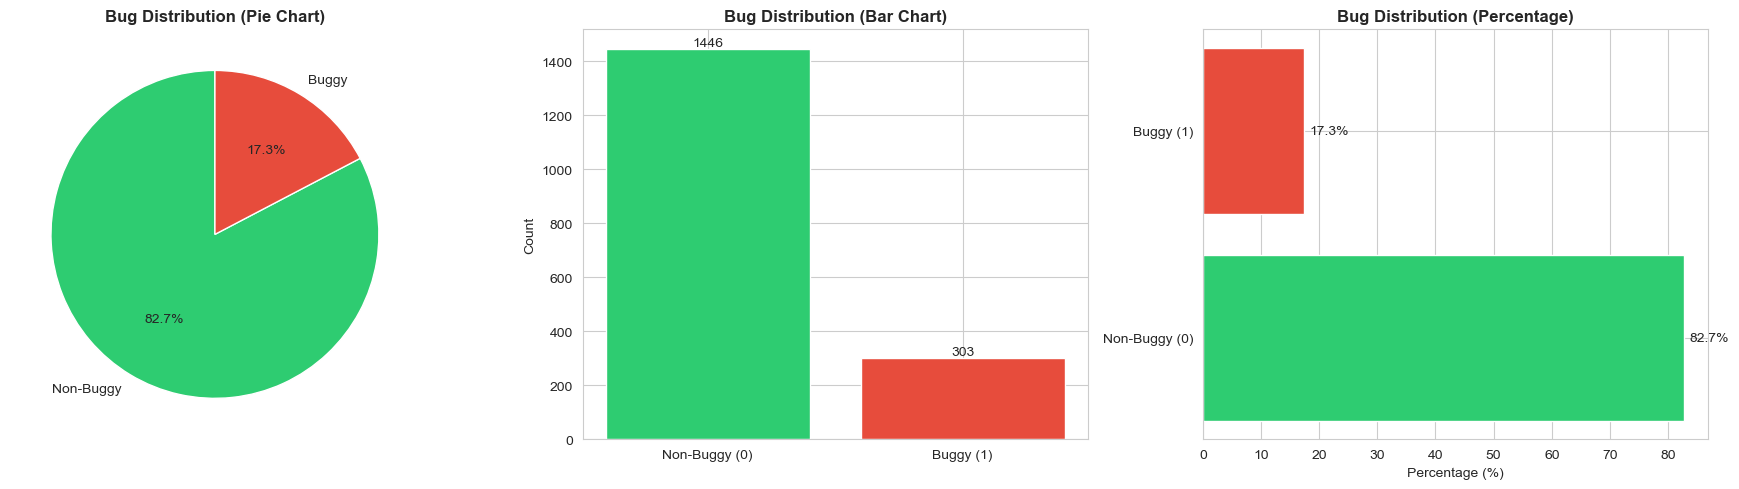


4. OUTLIER DETECTION & NOISE ANALYSIS

Outlier Summary (Top 10 columns):
Column  IQR_Outliers  IQR_Percentage  Z_Score_Outliers  Z_Score_Percentage
  lcom           260       14.865638                20            1.143511
   moa           256       14.636935                45            2.572899
    ca           177       10.120069                30            1.715266
   noc           163        9.319611                23            1.315037
   npm           153        8.747856                29            1.658090
   loc           150        8.576329                28            1.600915
   wmc           149        8.519154                25            1.429388
   cbo           142        8.118925                28            1.600915
    ic           134        7.661521                38            2.172670
   cbm           132        7.547170                64            3.659234


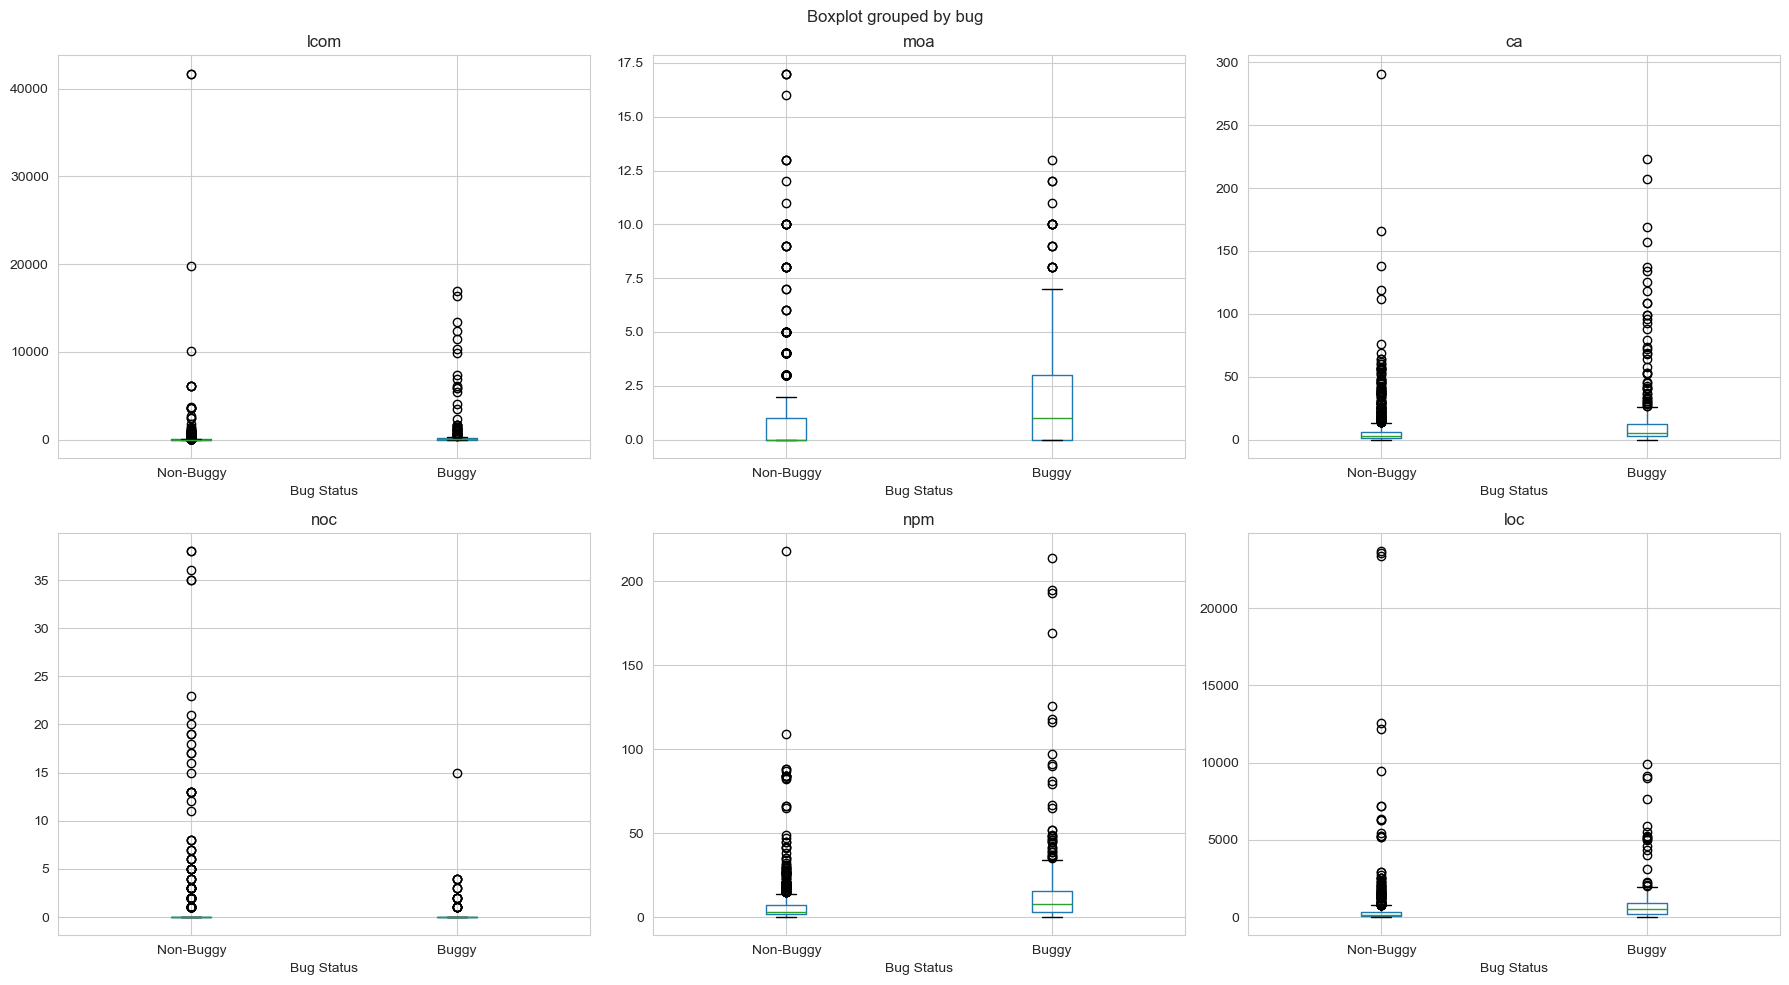


⚠️  3 columns have >10% outliers:
   ['lcom', 'moa', 'ca']

💡 Recommendations:
   • Consider log transformation or winsorization
   • Check if outliers are data errors or genuine extreme values
   • Robust scaling may help (RobustScaler)

5. CORRELATION ANALYSIS

Top 10 Features Correlated with Bug:
rfc       0.319726
ce        0.284868
moa       0.250109
cam      -0.241637
dam       0.233925
npm       0.232439
cbo       0.225049
max_cc    0.201853
avg_cc    0.195997
ca        0.194231
Name: bug, dtype: float64


Multicollinearity Detection (|correlation| > 0.8):
────────────────────────────────────────────────────────────
Feature_1 Feature_2  Correlation
      cbo        ca     0.964201
      wmc       loc     0.931821
      wmc       rfc     0.868452
      rfc        ce     0.842010
      wmc       npm     0.829767
       ic       cbm     0.826344
      rfc       npm     0.825406

⚠️  Found 7 highly correlated feature pairs
💡  Consider removing redundant features or using PCA


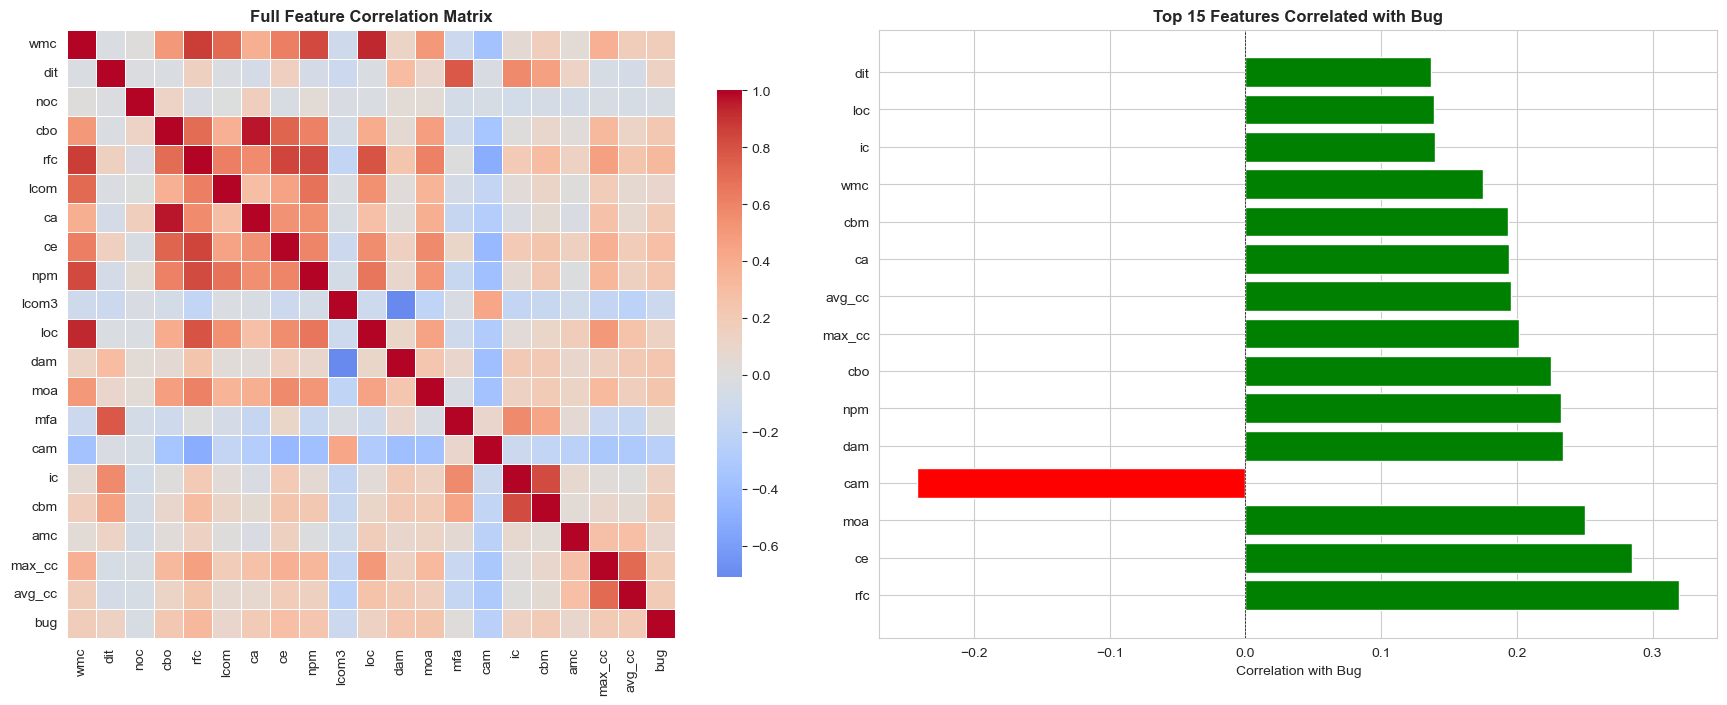


6. FEATURE DISTRIBUTION ANALYSIS

Normality Test Results (Shapiro-Wilk, p > 0.05 = Normal):
────────────────────────────────────────────────────────────
Feature  Statistic      P-Value Normal
    cam   0.941711 1.080507e-25     No
  lcom3   0.831819 1.753754e-39     No
    dit   0.754580 3.754637e-45     No
    mfa   0.749733 1.863953e-45     No
    dam   0.725482 6.573070e-47     No
     ce   0.688000 5.868214e-49     No
     ic   0.685433 4.322598e-49     No
 avg_cc   0.657197 1.705967e-50     No
    amc   0.573248 3.649456e-54     No
    moa   0.569280 2.536591e-54     No

📊 20/20 features are non-normal
💡 Consider transformation (log, sqrt, box-cox) for non-normal features


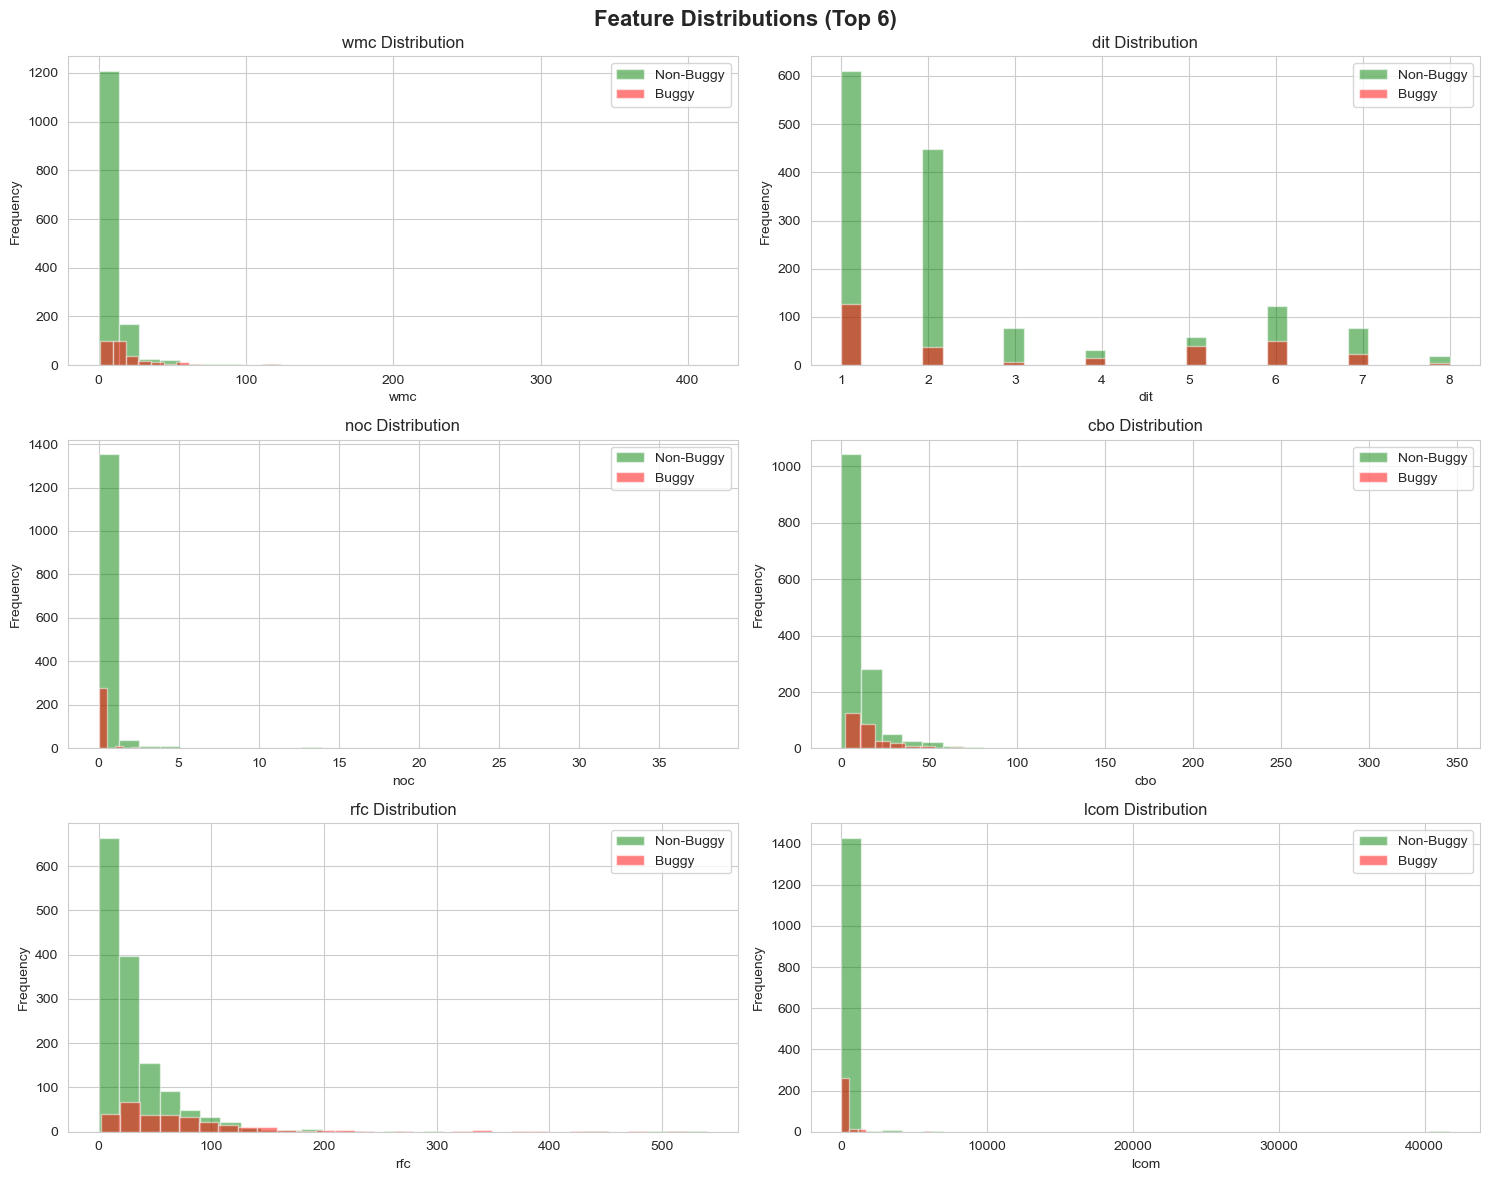


7. DIMENSIONALITY REDUCTION & VISUALIZATION

PCA Analysis:
  • Components needed for 95% variance: 13/20
  • Variance explained by first 10 components: 90.6%


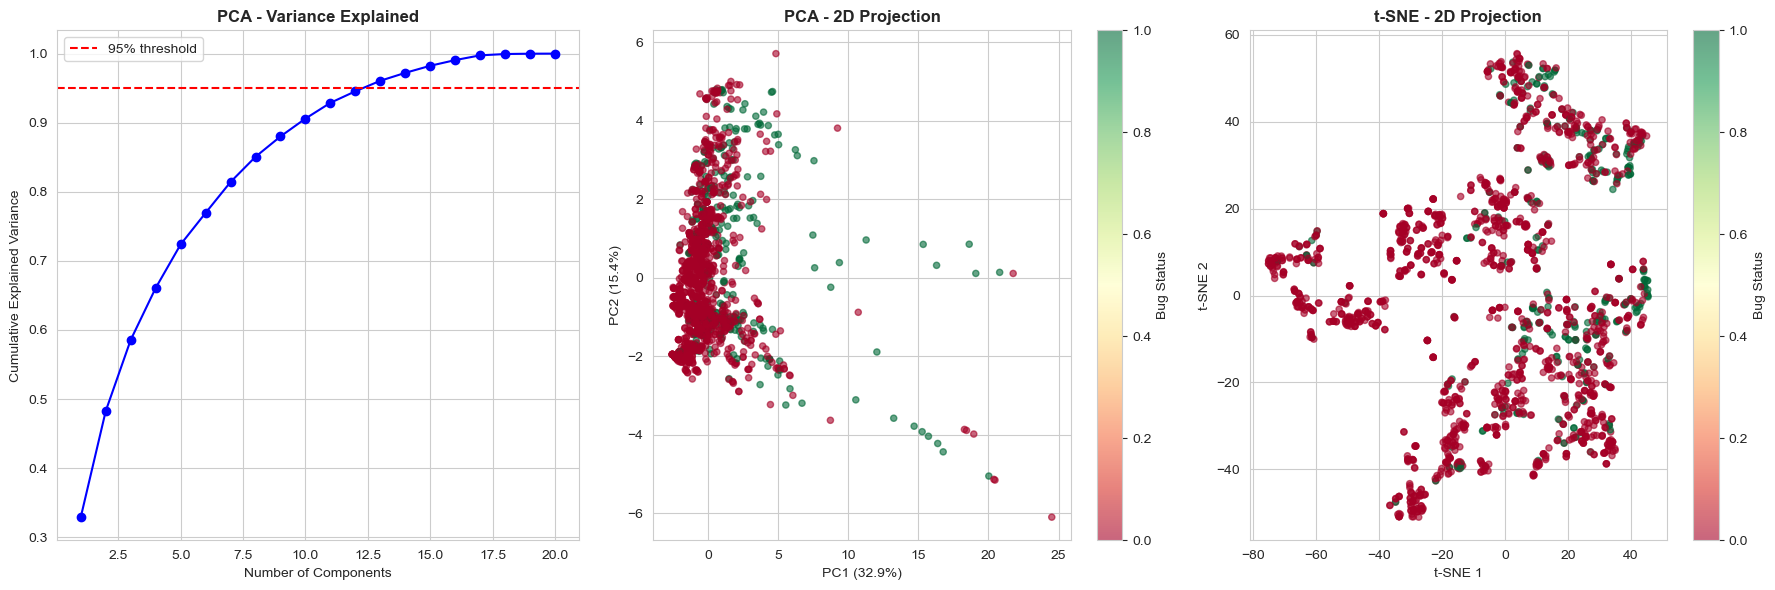


💡 Insights:
   • Data is spread across many dimensions (complex dataset)
   • Check t-SNE plot: clear clusters = good separability

8. FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
Feature  Importance
    loc    0.095668
    rfc    0.087867
 avg_cc    0.072772
    amc    0.071361
   lcom    0.066079
    cbo    0.061638
    wmc    0.057058
     ca    0.055619
    cam    0.055228
 max_cc    0.054972
  lcom3    0.054687
     ce    0.054216
    mfa    0.040231
    npm    0.039122
    moa    0.035220
    dam    0.034314
    cbm    0.020506
    dit    0.019361
     ic    0.013648
    noc    0.010432


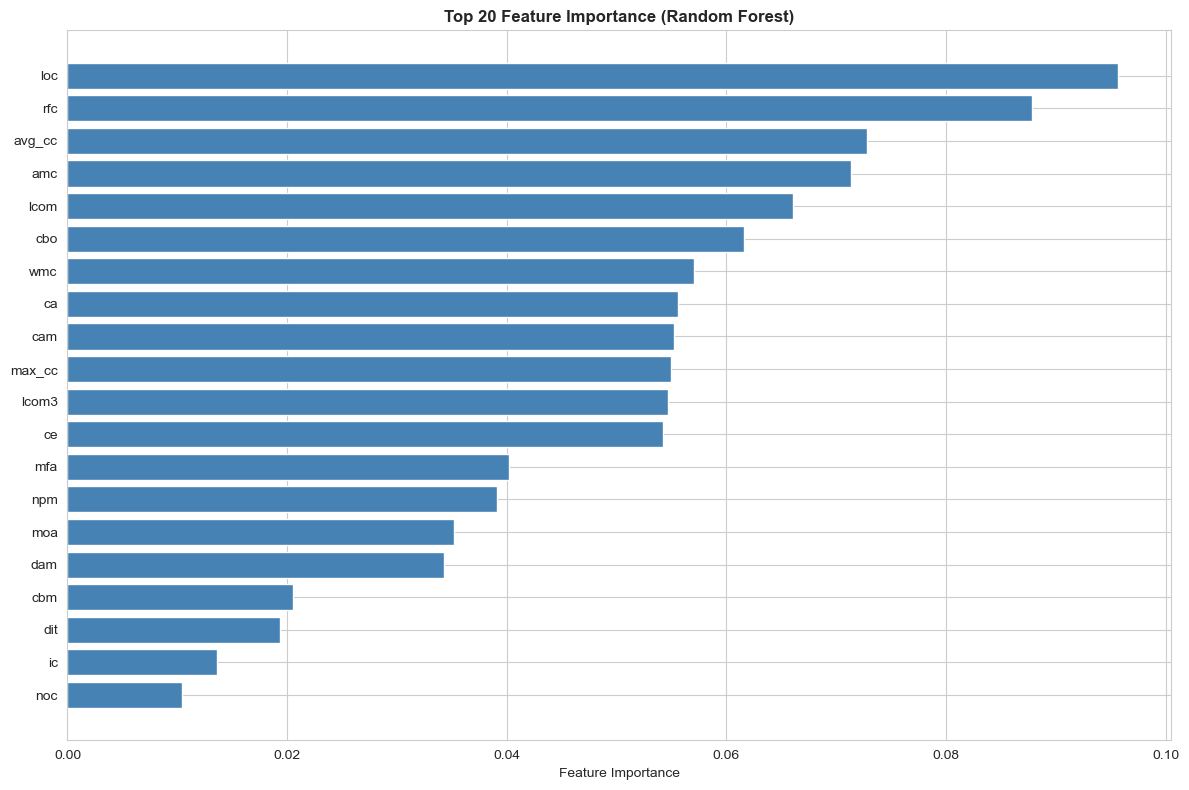


💡 Insight: Top 13 features explain 80% of importance
   Consider feature selection to reduce dimensionality

9. COMPREHENSIVE SUMMARY REPORT

DATASET OVERVIEW
File: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv
Total Rows: 1,749
Total Features: 20
Missing Data: 0 cells

────────────────────────────────────────────────────────────
CLASS DISTRIBUTION
────────────────────────────────────────────────────────────
Non-Buggy (0): 1,446 (82.7%)
Buggy (1): 303 (17.3%)
Imbalance Ratio: 4.77:1

────────────────────────────────────────────────────────────
DATA QUALITY ISSUES
────────────────────────────────────────────────────────────
✅ No missing values

────────────────────────────────────────────────────────────
RECOMMENDATIONS
────────────────────────────────────────────────────────────
• Use SMOTE or undersampling for class imbalance
• Apply feature scaling (StandardScaler or RobustScaler)
• Consider feature selection to reduce dimensionality
• Monitor for overfitting with cross-va

UnicodeEncodeError: 'charmap' codec can't encode characters in position 269-328: character maps to <undefined>

In [7]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv"
    
analyzer = BugDatasetAnalyzer(file_path, target_column='bug')
analyzer.run_complete_analysis()


LOADING DATASET: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv

✅ Dataset loaded successfully!
   Shape: (704, 21)
   Columns: 21
   Rows: 704

1. BASIC DATASET INFORMATION

Dataset Preview (First 5 rows):
   wmc  dit  noc  cbo  rfc  lcom  ca  ce  npm     lcom3  ...    dam  moa  \
0    2    1    0    8    2     1   7   1    2  2.000000  ...  0.000    0   
1   23    1    0    7   52   171   2   5   20  0.837662  ...  1.000    2   
2    4    1    0   10    4     6   9   1    4  2.000000  ...  0.000    0   
3   13    4    2   17   57    22   2  15    9  0.250000  ...  1.000    1   
4   38    2    0   37  153   569   1  37   21  0.895270  ...  0.875    1   

        mfa       cam  ic  cbm        amc  max_cc  avg_cc  bug  
0  0.000000  0.666667   0    0   0.000000       1  1.0000    0  
1  0.000000  0.250000   0    0  16.956522       4  1.4348    3  
2  0.000000  0.550000   0    0   0.000000       1  1.0000    1  
3  0.850000  0.192308   3    7  25.538462       6  1.6154    6  
4

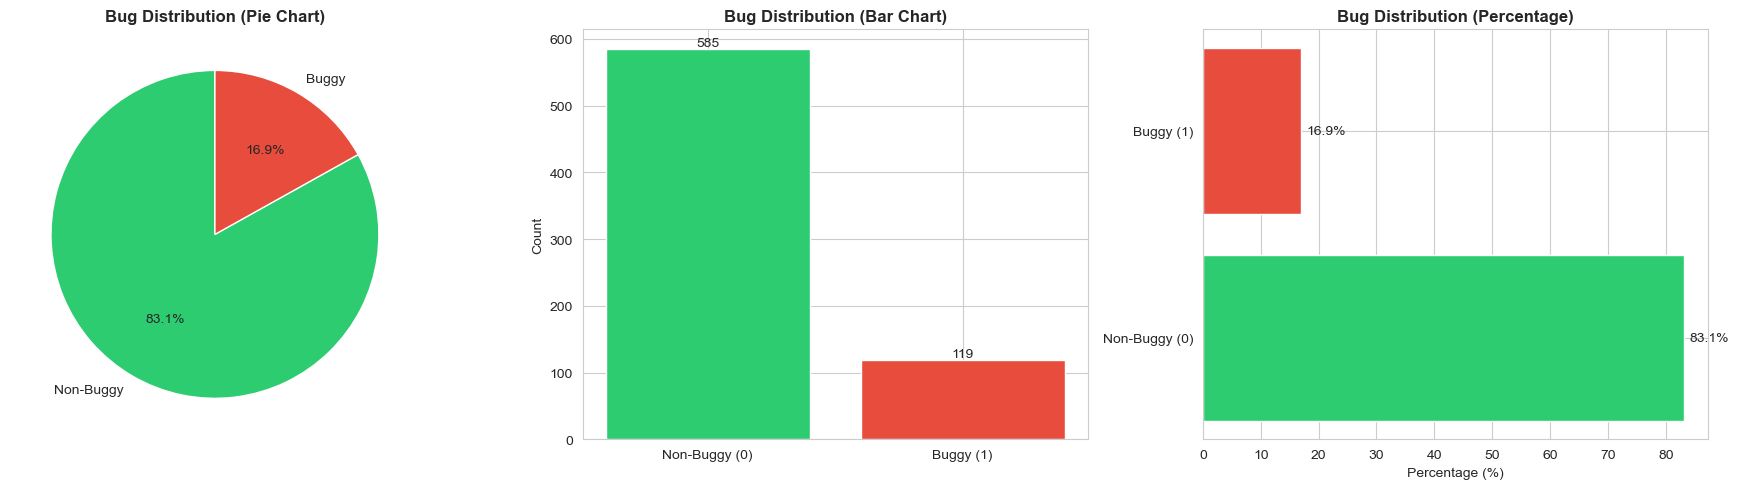


4. OUTLIER DETECTION & NOISE ANALYSIS

Outlier Summary (Top 10 columns):
Column  IQR_Outliers  IQR_Percentage  Z_Score_Outliers  Z_Score_Percentage
  lcom           104       14.772727                 5            0.710227
   dit            96       13.636364                18            2.556818
   noc            90       12.784091                14            1.988636
   loc            87       12.357955                11            1.562500
    ca            77       10.937500                15            2.130682
   cbo            60        8.522727                13            1.846591
   amc            58        8.238636                19            2.698864
   cbm            55        7.812500                18            2.556818
   rfc            54        7.670455                11            1.562500
max_cc            50        7.102273                17            2.414773


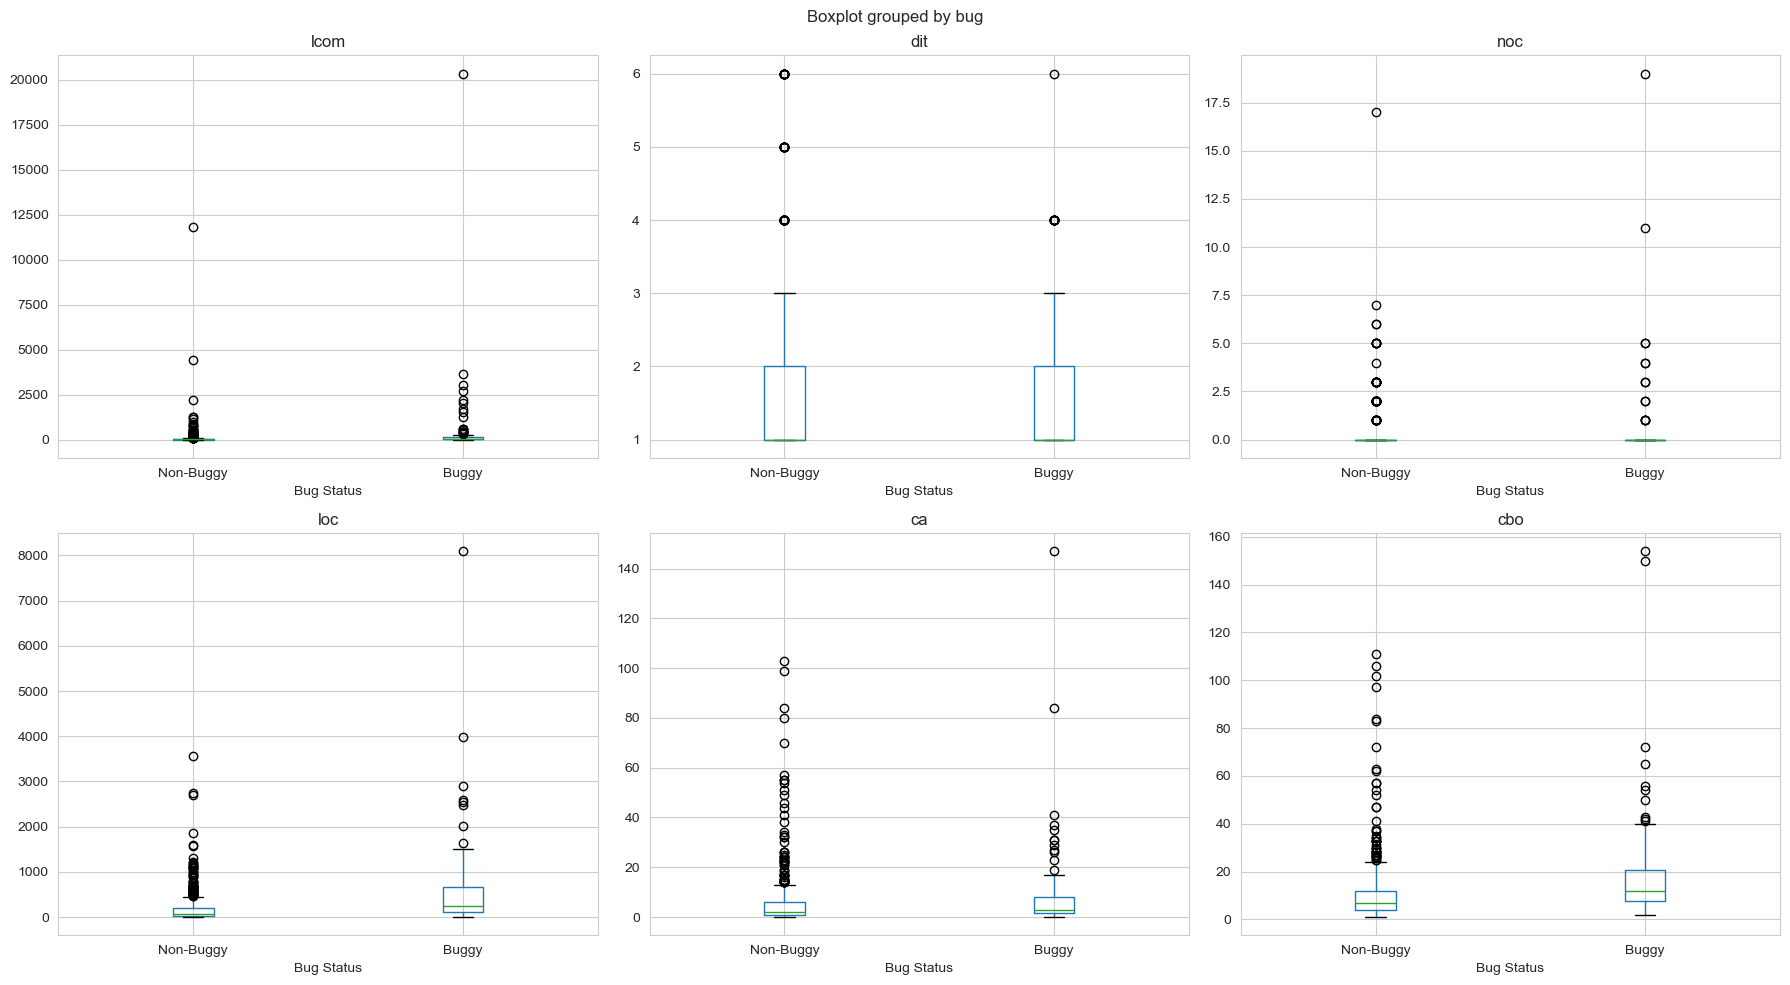


⚠️  5 columns have >10% outliers:
   ['lcom', 'dit', 'noc', 'loc', 'ca']

💡 Recommendations:
   • Consider log transformation or winsorization
   • Check if outliers are data errors or genuine extreme values
   • Robust scaling may help (RobustScaler)

5. CORRELATION ANALYSIS

Top 10 Features Correlated with Bug:
rfc       0.314458
loc       0.285831
ce        0.276868
cam      -0.252007
wmc       0.247287
npm       0.209705
max_cc    0.205544
cbo       0.195664
amc       0.190389
moa       0.154045
Name: bug, dtype: float64


Multicollinearity Detection (|correlation| > 0.8):
────────────────────────────────────────────────────────────
Feature_1 Feature_2  Correlation
      wmc       npm     0.964648
      rfc       loc     0.951556
      wmc       rfc     0.886907
    lcom3       dam    -0.872344
      cbo        ca     0.861454
      dit       mfa     0.856929
      wmc       loc     0.840808
       ic       cbm     0.822435
     lcom       npm     0.808631
      rfc       npm     

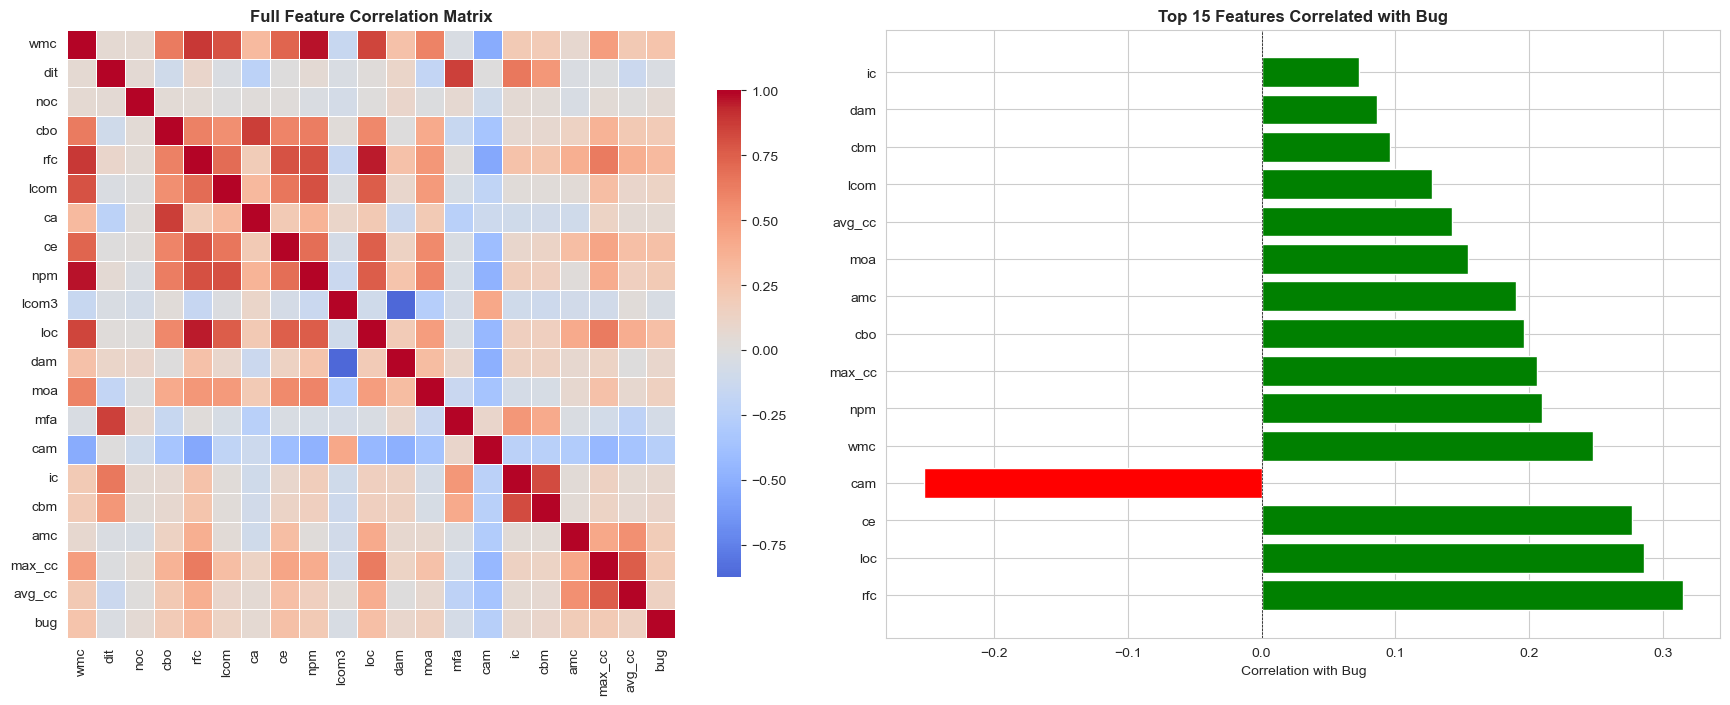


6. FEATURE DISTRIBUTION ANALYSIS

Normality Test Results (Shapiro-Wilk, p > 0.05 = Normal):
────────────────────────────────────────────────────────────
Feature  Statistic      P-Value Normal
    cam   0.935364 6.729557e-17     No
  lcom3   0.837648 3.609852e-26     No
 avg_cc   0.770277 3.160922e-30     No
    mfa   0.705630 2.580686e-33     No
    dit   0.681100 2.405382e-34     No
    dam   0.670923 9.381250e-35     No
 max_cc   0.642572 7.661225e-36     No
    rfc   0.608558 4.648260e-37     No
    amc   0.581741 5.845112e-38     No
     ic   0.574875 3.497726e-38     No

📊 20/20 features are non-normal
💡 Consider transformation (log, sqrt, box-cox) for non-normal features


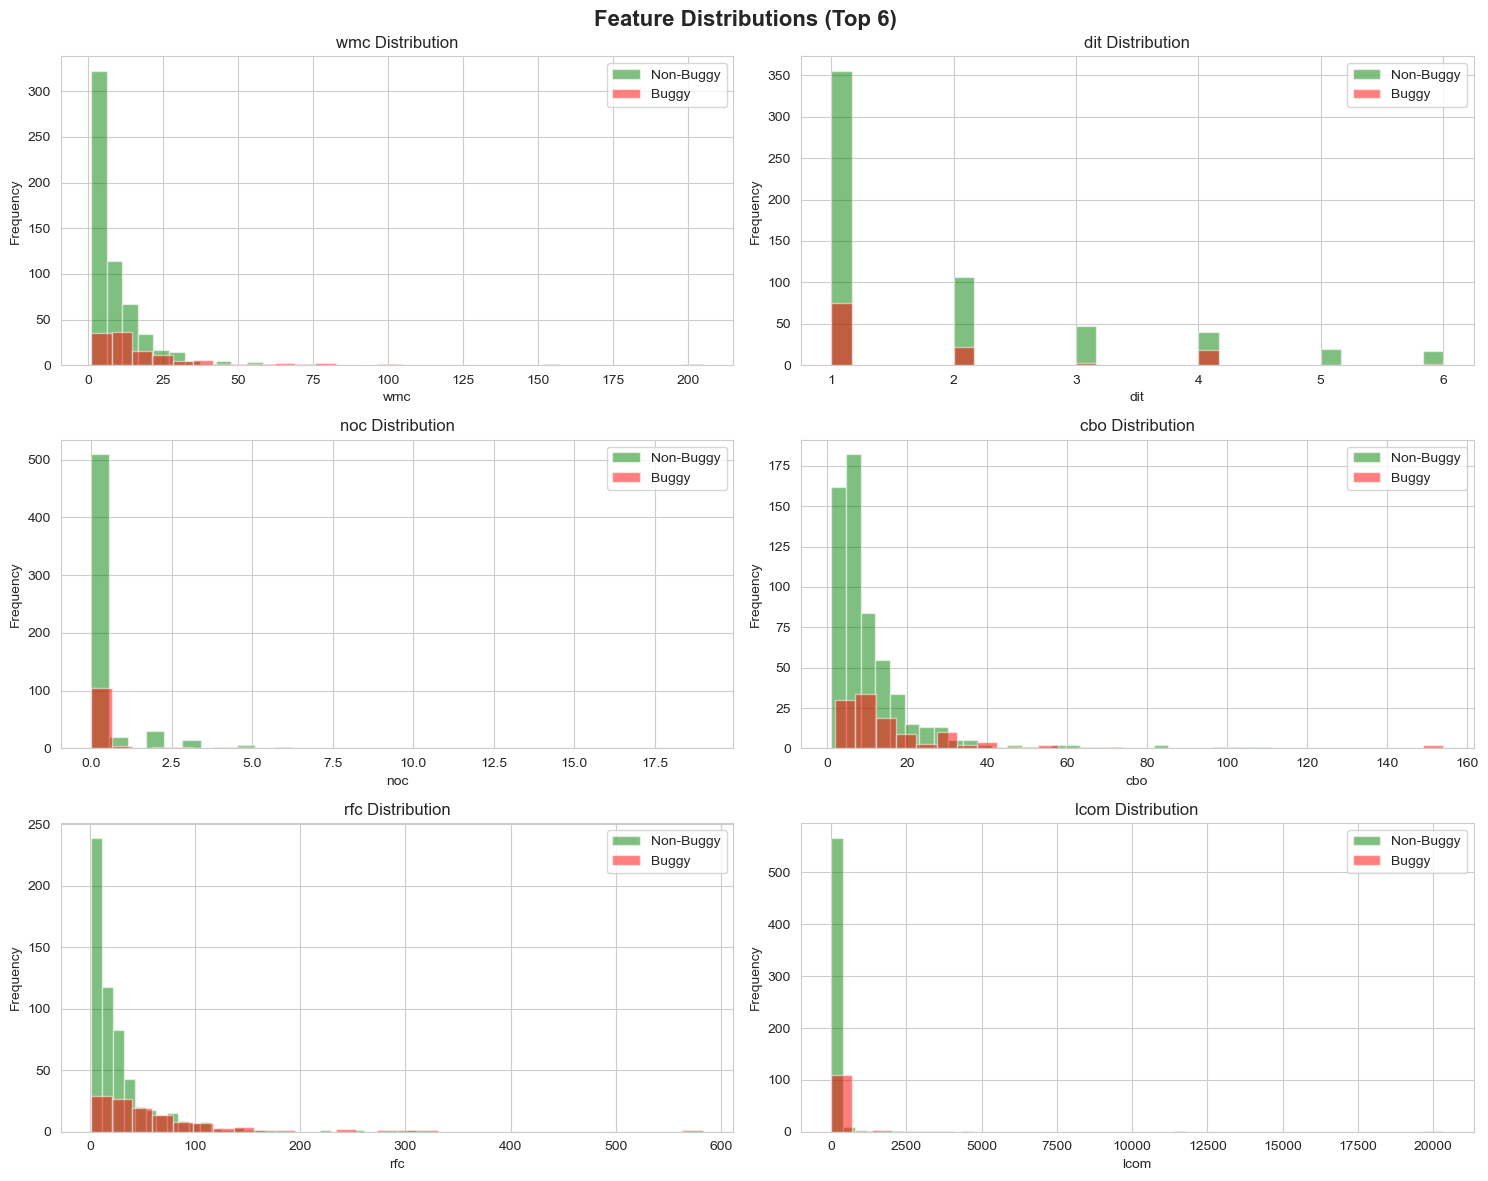


7. DIMENSIONALITY REDUCTION & VISUALIZATION

PCA Analysis:
  • Components needed for 95% variance: 11/20
  • Variance explained by first 10 components: 93.9%


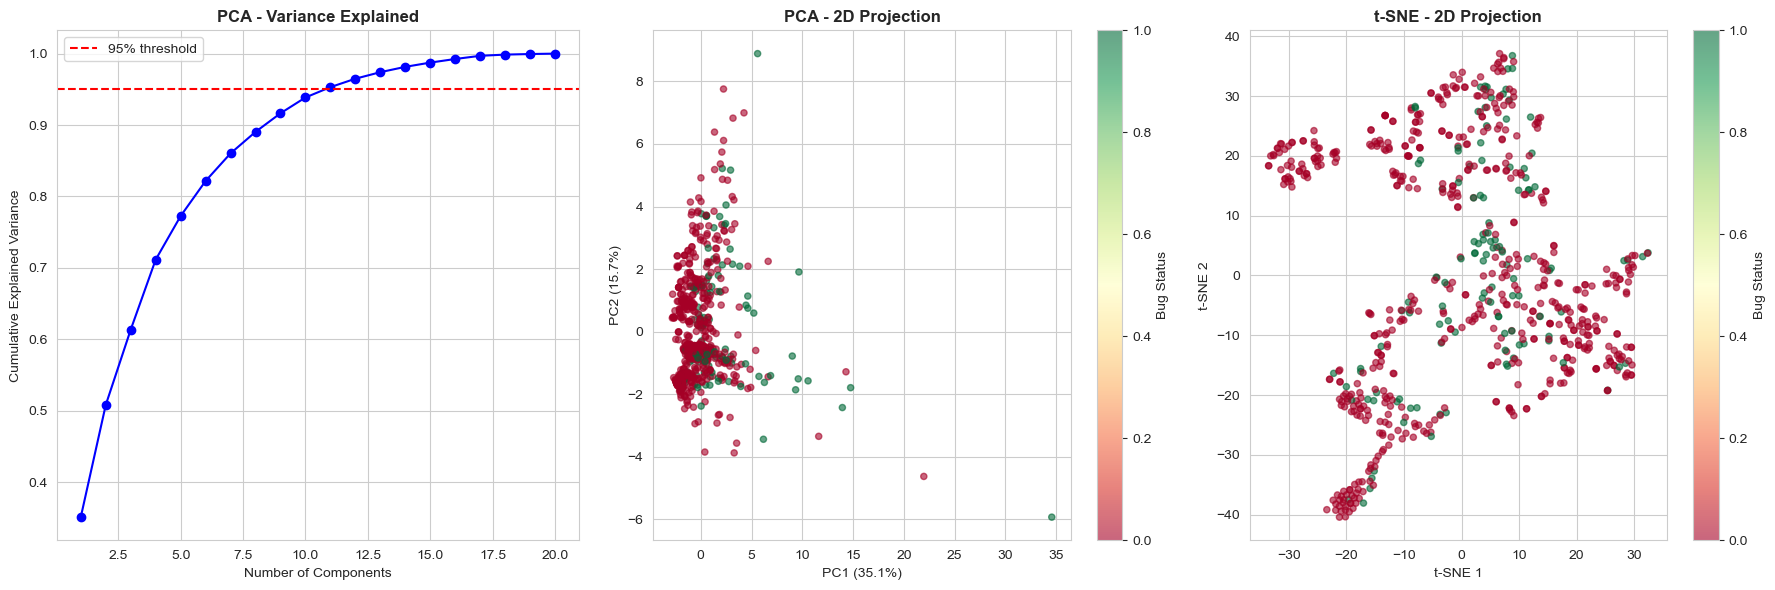


💡 Insights:
   • First 2 PCA components capture >51% variance (good)
   • Check t-SNE plot: clear clusters = good separability

8. FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
Feature  Importance
    loc    0.111090
    amc    0.083237
    cam    0.083043
    rfc    0.082024
     ce    0.078819
    cbo    0.064929
   lcom    0.064617
 avg_cc    0.064420
    wmc    0.057615
     ca    0.053923
  lcom3    0.051000
    npm    0.047712
 max_cc    0.036701
    mfa    0.031100
    moa    0.023121
    cbm    0.017932
    dam    0.014374
    dit    0.013480
    noc    0.012514
     ic    0.008349


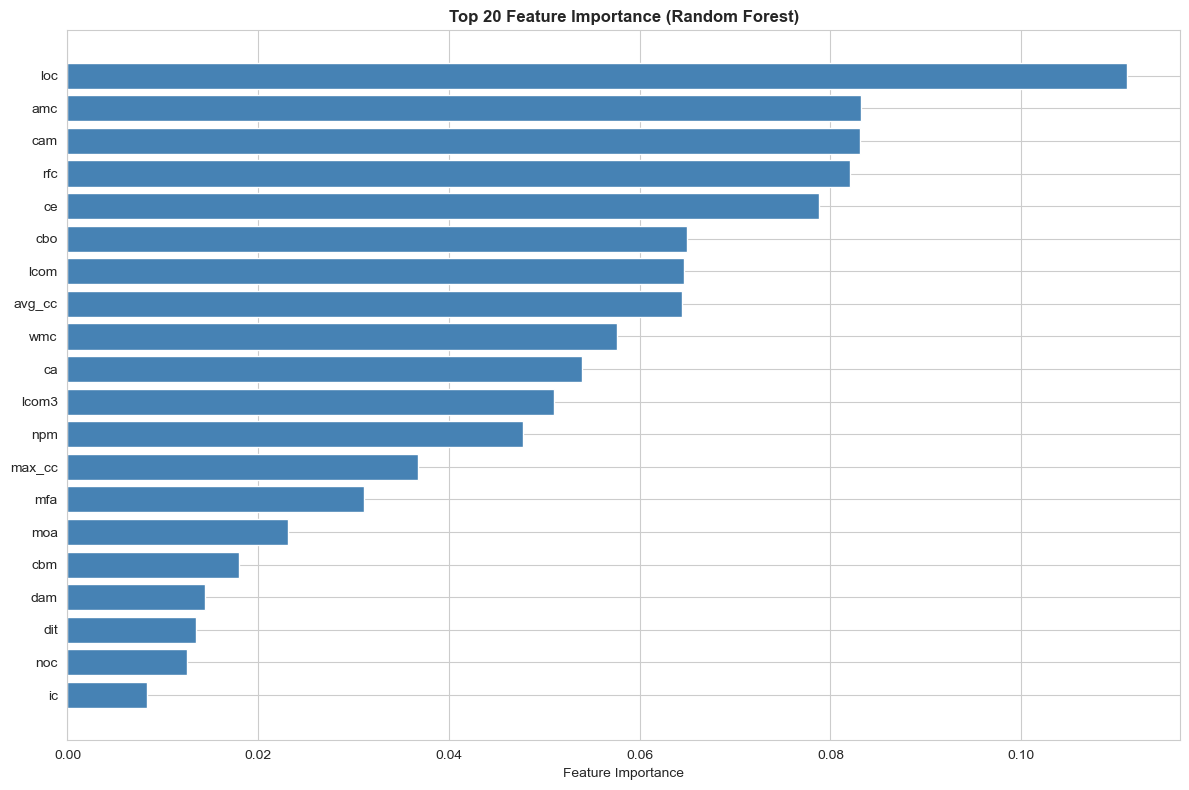


💡 Insight: Top 12 features explain 80% of importance
   Consider feature selection to reduce dimensionality

9. COMPREHENSIVE SUMMARY REPORT

DATASET OVERVIEW
File: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv
Total Rows: 704
Total Features: 20
Missing Data: 0 cells

────────────────────────────────────────────────────────────
CLASS DISTRIBUTION
────────────────────────────────────────────────────────────
Non-Buggy (0): 585 (83.1%)
Buggy (1): 119 (16.9%)
Imbalance Ratio: 4.92:1

────────────────────────────────────────────────────────────
DATA QUALITY ISSUES
────────────────────────────────────────────────────────────
✅ No missing values

────────────────────────────────────────────────────────────
RECOMMENDATIONS
────────────────────────────────────────────────────────────
• Use SMOTE or undersampling for class imbalance
• Apply feature scaling (StandardScaler or RobustScaler)
• Consider feature selection to reduce dimensionality
• Monitor for overfitting with cross-valida

UnicodeEncodeError: 'charmap' codec can't encode characters in position 267-326: character maps to <undefined>

In [9]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv"
    
analyzer = BugDatasetAnalyzer(file_path, target_column='bug')
analyzer.run_complete_analysis()


LOADING DATASET: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv

✅ Dataset loaded successfully!
   Shape: (2784, 21)
   Columns: 21
   Rows: 2784

1. BASIC DATASET INFORMATION

Dataset Preview (First 5 rows):
   wmc  dit  noc  cbo  rfc  lcom  ca  ce  npm  lcom3  ...  dam  moa       mfa  \
0    4    2    0    6    8     6   2   5    4   2.00  ...  0.0    0  0.896552   
1    6    3    0   21   33    15   1  21    2   2.00  ...  0.0    0  0.800000   
2    2    3    0    3    7     1   0   3    1   2.00  ...  0.0    0  0.833333   
3   26    1    1   10   47     0   5   5   24   0.08  ...  1.0    1  0.000000   
4    4    3    0    4   19     6   1   4    3   2.00  ...  0.0    0  0.888889   

        cam  ic  cbm        amc  max_cc  avg_cc  bug  
0  0.500000   0    0   5.500000       1  0.7500    0  
1  0.500000   2    2  28.333333       1  0.6667    0  
2  0.666667   1    1  11.000000       1  0.5000    0  
3  0.258242   0    0   8.038462       2  1.0000    0  
4  0.375000   1    

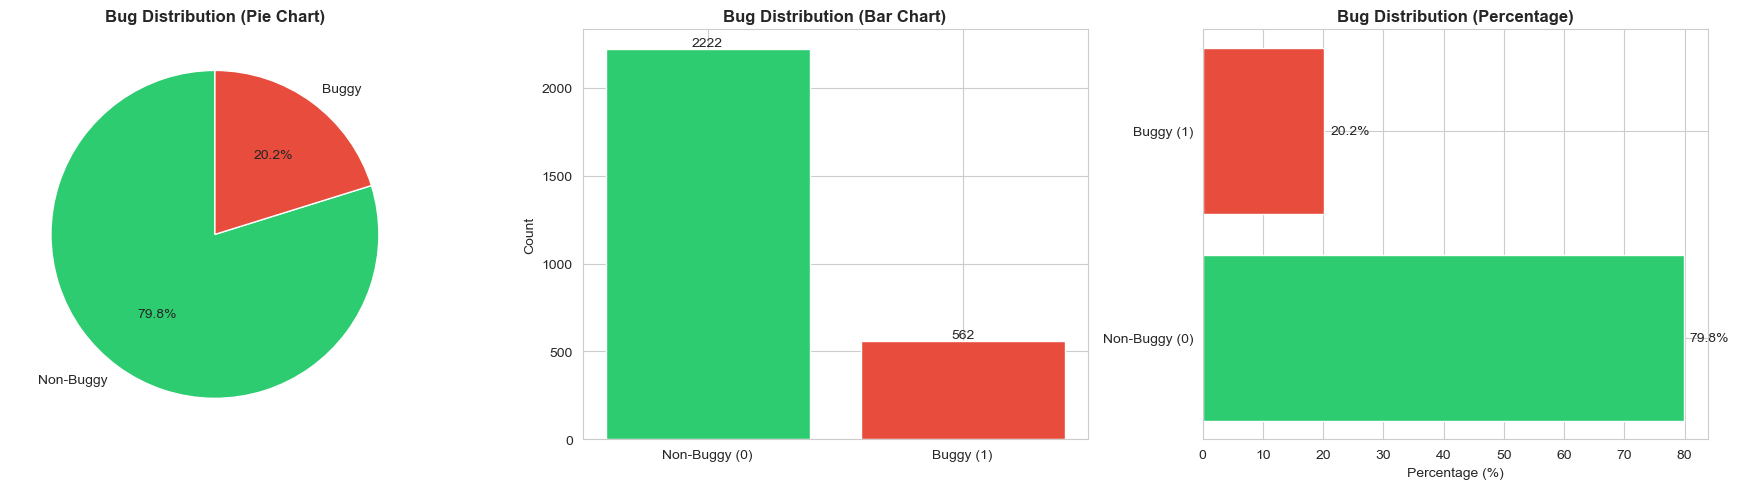


4. OUTLIER DETECTION & NOISE ANALYSIS

Outlier Summary (Top 10 columns):
Column  IQR_Outliers  IQR_Percentage  Z_Score_Outliers  Z_Score_Percentage
max_cc           435       15.625000                49            1.760057
avg_cc           434       15.589080                51            1.831897
  lcom           400       14.367816                18            0.646552
   noc           339       12.176724                50            1.795977
    ca           260        9.339080                35            1.257184
   npm           225        8.081897                55            1.975575
   cbm           207        7.435345                30            1.077586
   moa           202        7.255747                47            1.688218
   loc           200        7.183908                65            2.334770
   amc           184        6.609195                60            2.155172


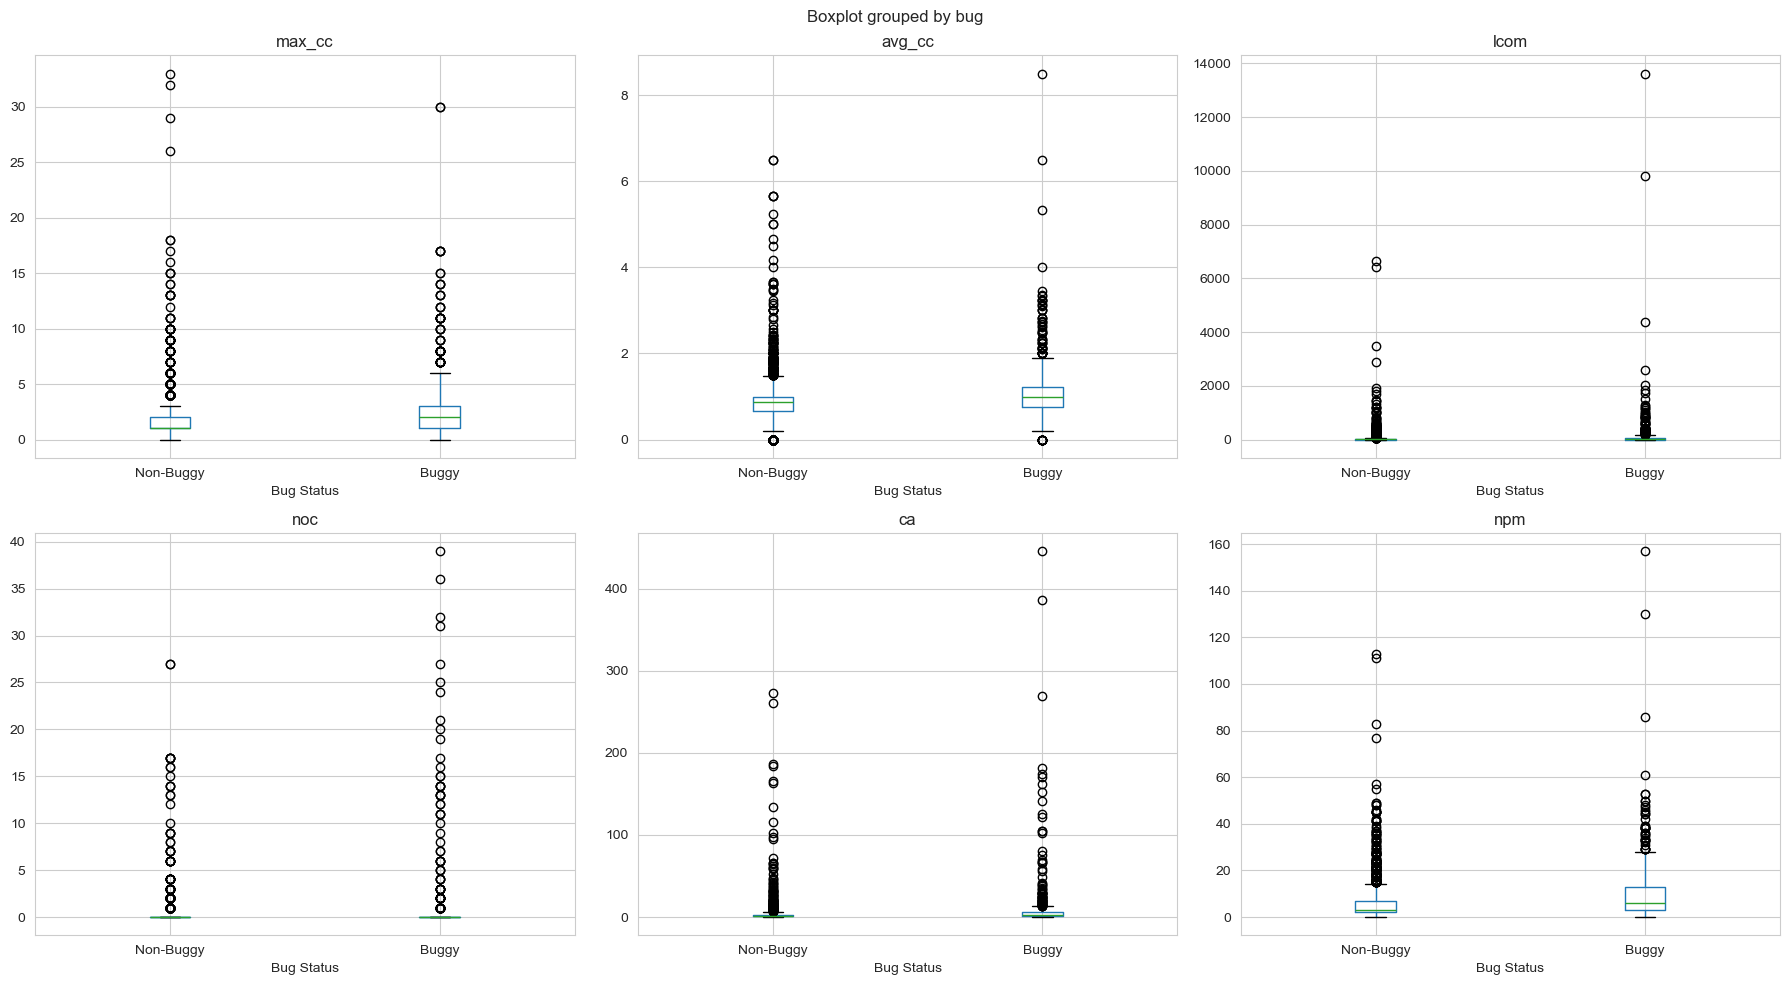


⚠️  4 columns have >10% outliers:
   ['max_cc', 'avg_cc', 'lcom', 'noc']

💡 Recommendations:
   • Consider log transformation or winsorization
   • Check if outliers are data errors or genuine extreme values
   • Robust scaling may help (RobustScaler)

5. CORRELATION ANALYSIS

Top 10 Features Correlated with Bug:
wmc       0.179545
npm       0.176640
loc       0.173568
rfc       0.172205
max_cc    0.155390
cbo       0.145907
noc       0.140931
ca        0.128997
cam      -0.128095
avg_cc    0.124179
Name: bug, dtype: float64


Multicollinearity Detection (|correlation| > 0.8):
────────────────────────────────────────────────────────────
Feature_1 Feature_2  Correlation
      wmc       npm     0.977528
      cbo        ca     0.960228
      rfc       loc     0.947911
    lcom3       dam    -0.897550
      wmc       rfc     0.876299
      dit       mfa     0.842395
      wmc       loc     0.823618

⚠️  Found 7 highly correlated feature pairs
💡  Consider removing redundant features or us

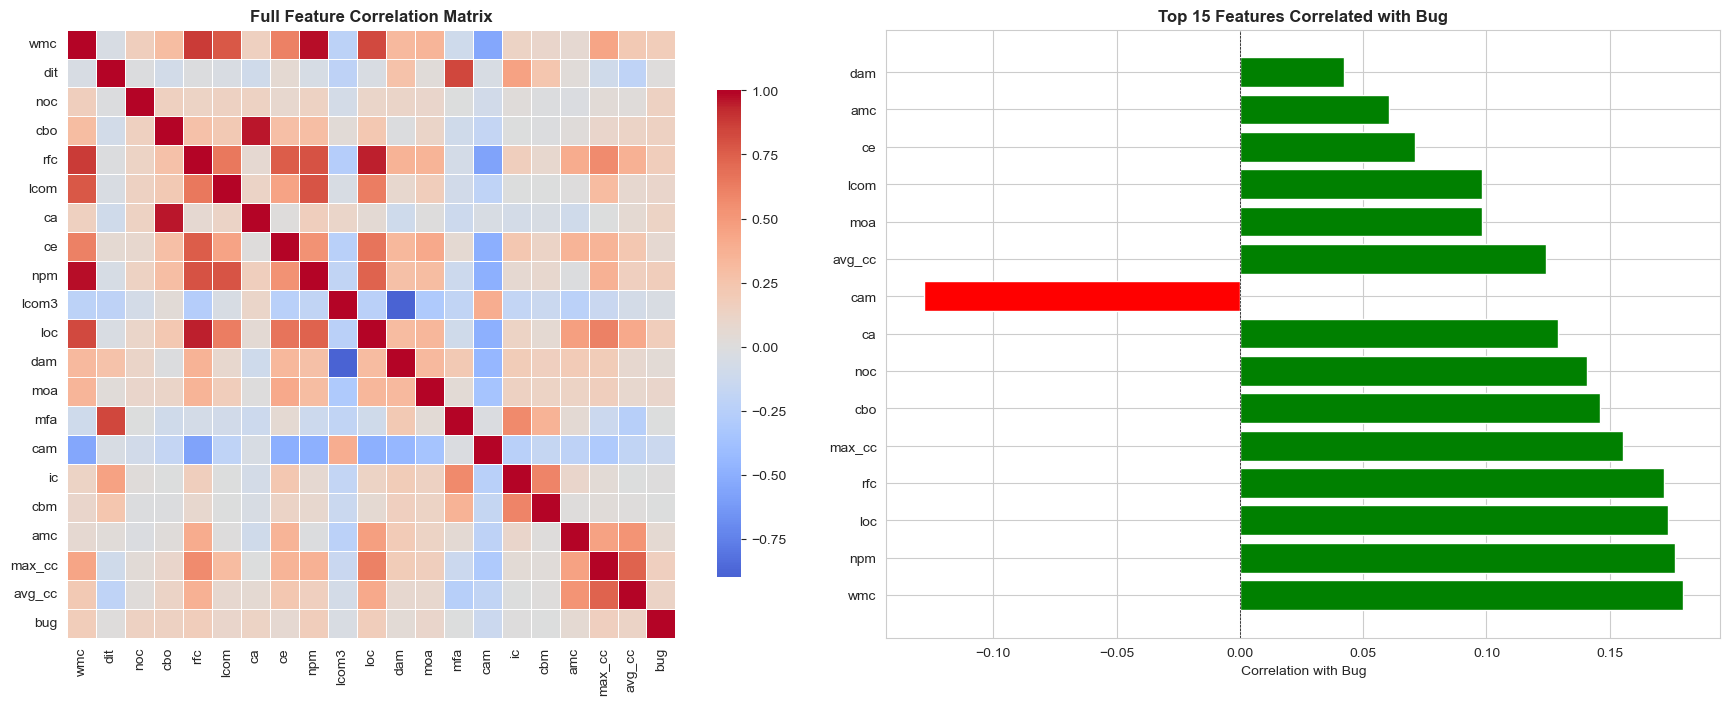


6. FEATURE DISTRIBUTION ANALYSIS

Normality Test Results (Shapiro-Wilk, p > 0.05 = Normal):
────────────────────────────────────────────────────────────
Feature  Statistic      P-Value Normal
    cam   0.938470 1.636643e-32     No
    dit   0.842944 3.125447e-46     No
  lcom3   0.824253 4.785485e-48     No
     ce   0.783791 1.739503e-51     No
    mfa   0.762856 4.640656e-53     No
 avg_cc   0.742594 1.778179e-54     No
    rfc   0.734627 5.228374e-55     No
    amc   0.709291 1.294853e-56     No
     ic   0.642980 2.544895e-60     No
    dam   0.641109 2.040947e-60     No

📊 20/20 features are non-normal
💡 Consider transformation (log, sqrt, box-cox) for non-normal features


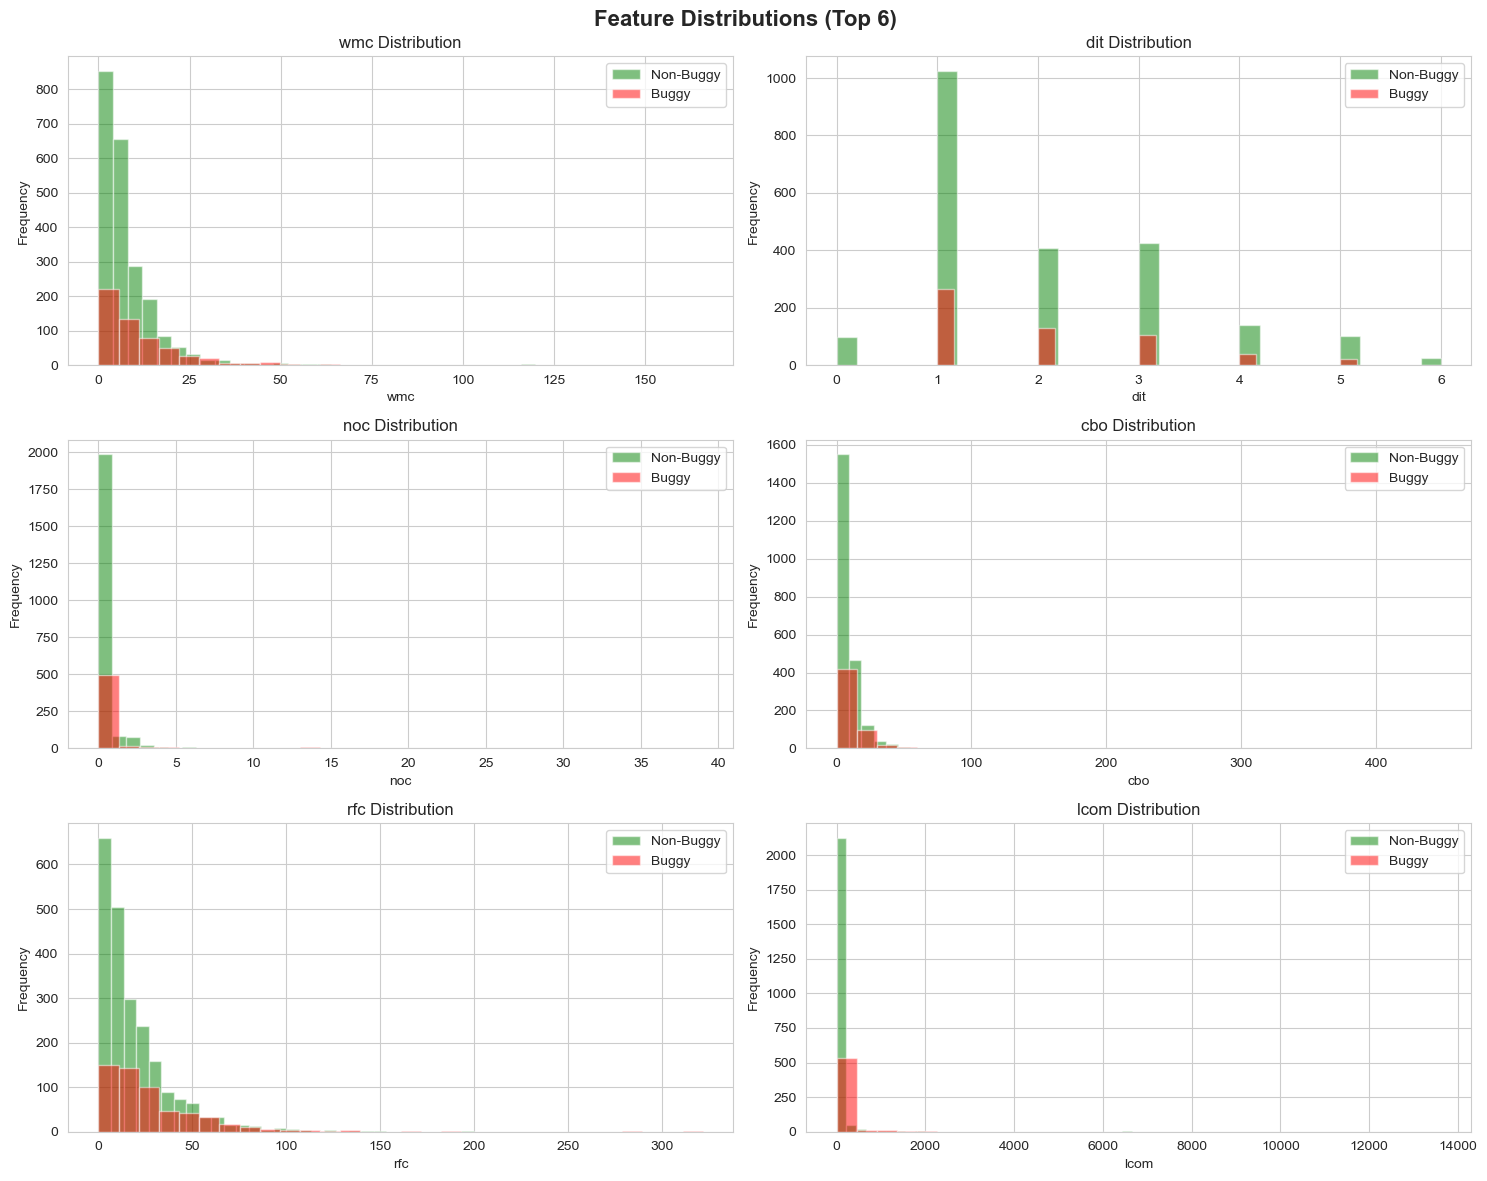


7. DIMENSIONALITY REDUCTION & VISUALIZATION

PCA Analysis:
  • Components needed for 95% variance: 12/20
  • Variance explained by first 10 components: 92.4%


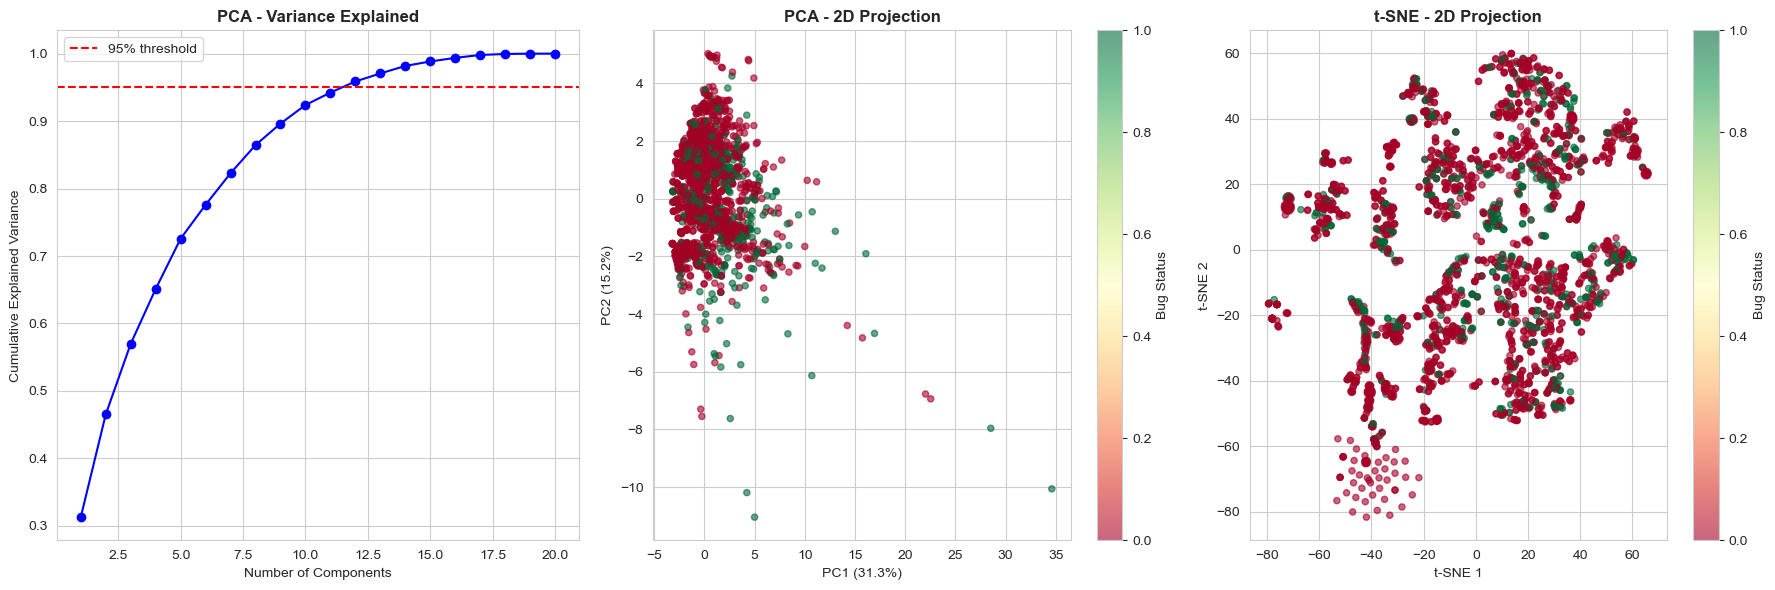


💡 Insights:
   • Data is spread across many dimensions (complex dataset)
   • Check t-SNE plot: clear clusters = good separability

8. FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
Feature  Importance
    mfa    0.086148
     ca    0.083028
    cbo    0.082433
    amc    0.074899
    loc    0.073777
    cam    0.069960
 avg_cc    0.061812
    rfc    0.061150
     ce    0.058519
  lcom3    0.051203
   lcom    0.049308
    wmc    0.046699
    npm    0.044843
 max_cc    0.031725
    dit    0.027815
    moa    0.026820
    noc    0.024840
    cbm    0.020367
    dam    0.013912
     ic    0.010743


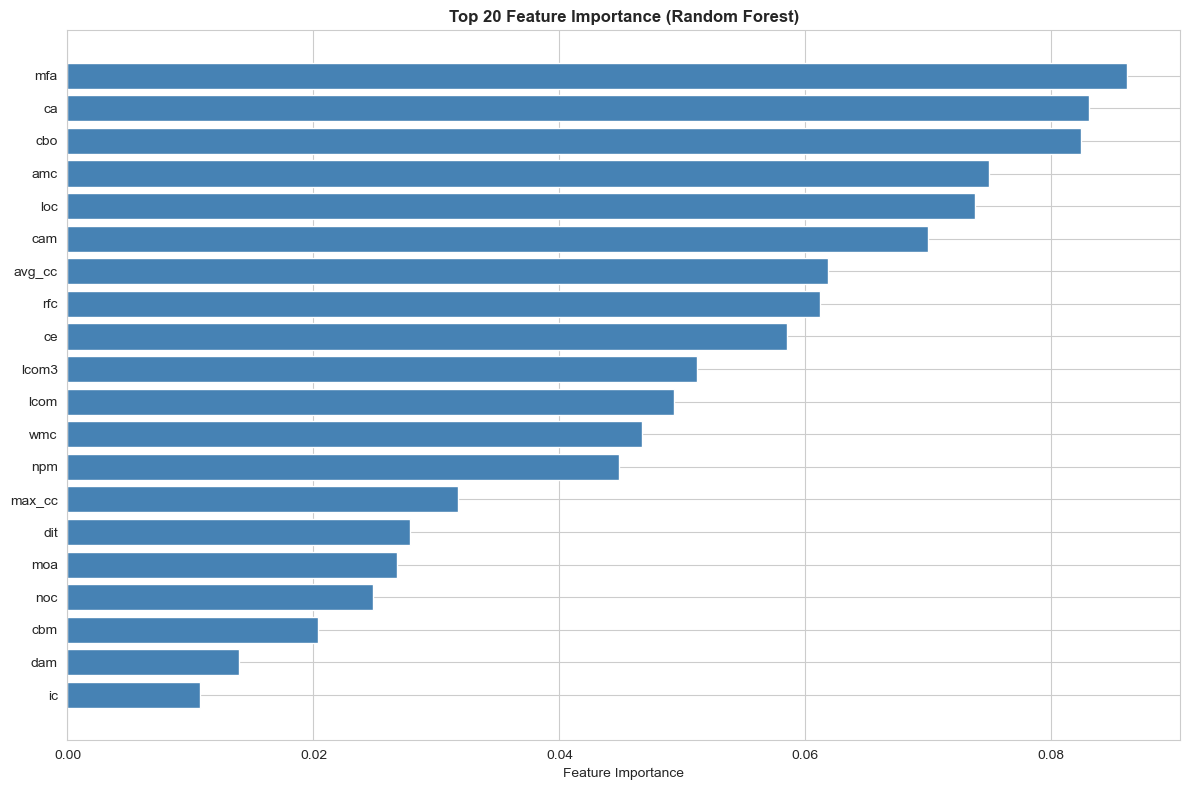


💡 Insight: Top 13 features explain 80% of importance
   Consider feature selection to reduce dimensionality

9. COMPREHENSIVE SUMMARY REPORT

DATASET OVERVIEW
File: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv
Total Rows: 2,784
Total Features: 20
Missing Data: 0 cells

────────────────────────────────────────────────────────────
CLASS DISTRIBUTION
────────────────────────────────────────────────────────────
Non-Buggy (0): 2,222 (79.8%)
Buggy (1): 562 (20.2%)
Imbalance Ratio: 3.95:1

────────────────────────────────────────────────────────────
DATA QUALITY ISSUES
────────────────────────────────────────────────────────────
✅ No missing values

────────────────────────────────────────────────────────────
RECOMMENDATIONS
────────────────────────────────────────────────────────────
• Use SMOTE or undersampling for class imbalance
• Apply feature scaling (StandardScaler or RobustScaler)
• Consider feature selection to reduce dimensionality
• Monitor for overfitting with cross-va

UnicodeEncodeError: 'charmap' codec can't encode characters in position 269-328: character maps to <undefined>

In [12]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv"
    
analyzer = BugDatasetAnalyzer(file_path, target_column='bug')
analyzer.run_complete_analysis()


LOADING DATASET: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv

✅ Dataset loaded successfully!
   Shape: (1692, 21)
   Columns: 21
   Rows: 1692

1. BASIC DATASET INFORMATION

Dataset Preview (First 5 rows):
   wmc  dit  noc  cbo  rfc  lcom  ca  ce  npm     lcom3  ...  dam  moa  \
0   11    4    2   14   42    29   2  12    5  0.725000  ...  1.0    1   
1   14    1    1    8   32    49   4   4   12  0.835165  ...  1.0    0   
2    3    2    0    1    9     0   0   1    1  0.000000  ...  1.0    1   
3   12    3    0   12   37    32   0  12   12  0.858586  ...  1.0    1   
4    6    3    0    4   21     1   0   4    6  0.700000  ...  1.0    0   

        mfa       cam  ic  cbm        amc  max_cc  avg_cc  bug  
0  0.885057  0.232323   3    4  34.545455       3  1.2727    0  
1  0.000000  0.307692   0    0  16.857143       6  1.6429    2  
2  0.714286  0.666667   1    1  17.333333       1  0.6667    0  
3  0.770833  0.458333   0    0  24.083333       3  1.4167    0  
4  0.880952

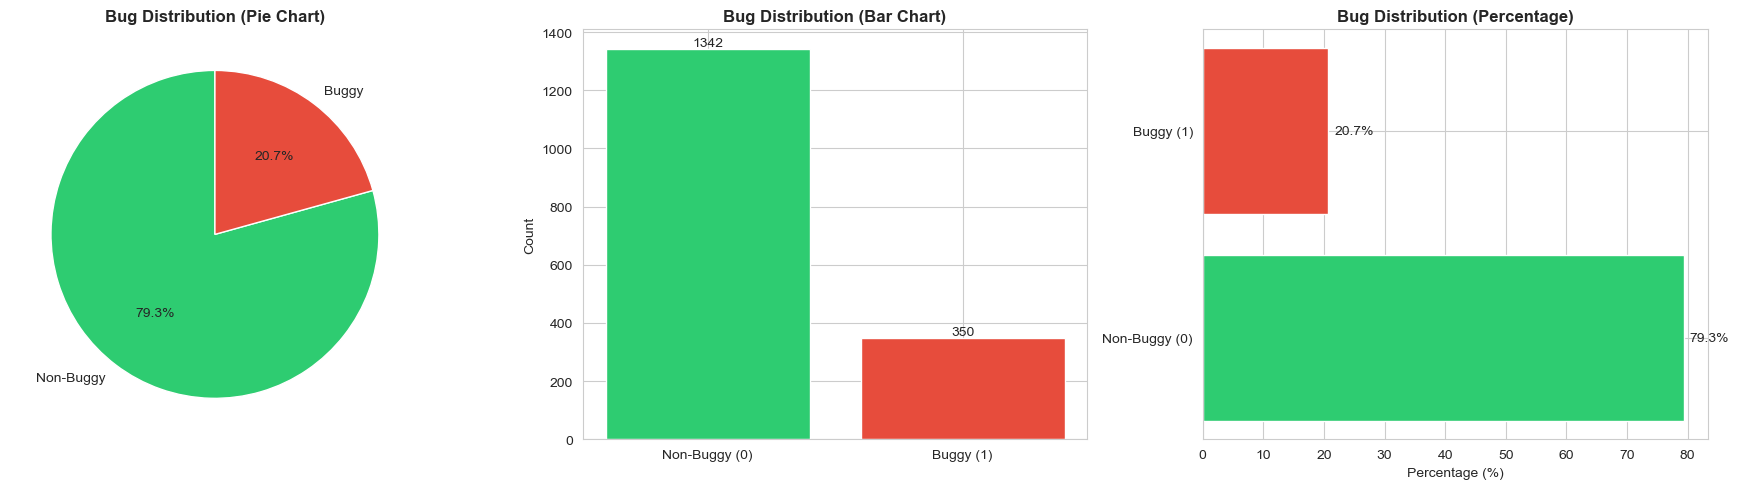


4. OUTLIER DETECTION & NOISE ANALYSIS

Outlier Summary (Top 10 columns):
Column  IQR_Outliers  IQR_Percentage  Z_Score_Outliers  Z_Score_Percentage
 lcom3           495       29.255319                 0            0.000000
  lcom           261       15.425532                23            1.359338
   noc           243       14.361702                14            0.827423
    ca           156        9.219858                23            1.359338
   cbo           149        8.806147                23            1.359338
   loc           137        8.096927                35            2.068558
   moa           130        7.683215                47            2.777778
   rfc           122        7.210402                27            1.595745
   npm           116        6.855792                30            1.773050
avg_cc           111        6.560284                43            2.541371


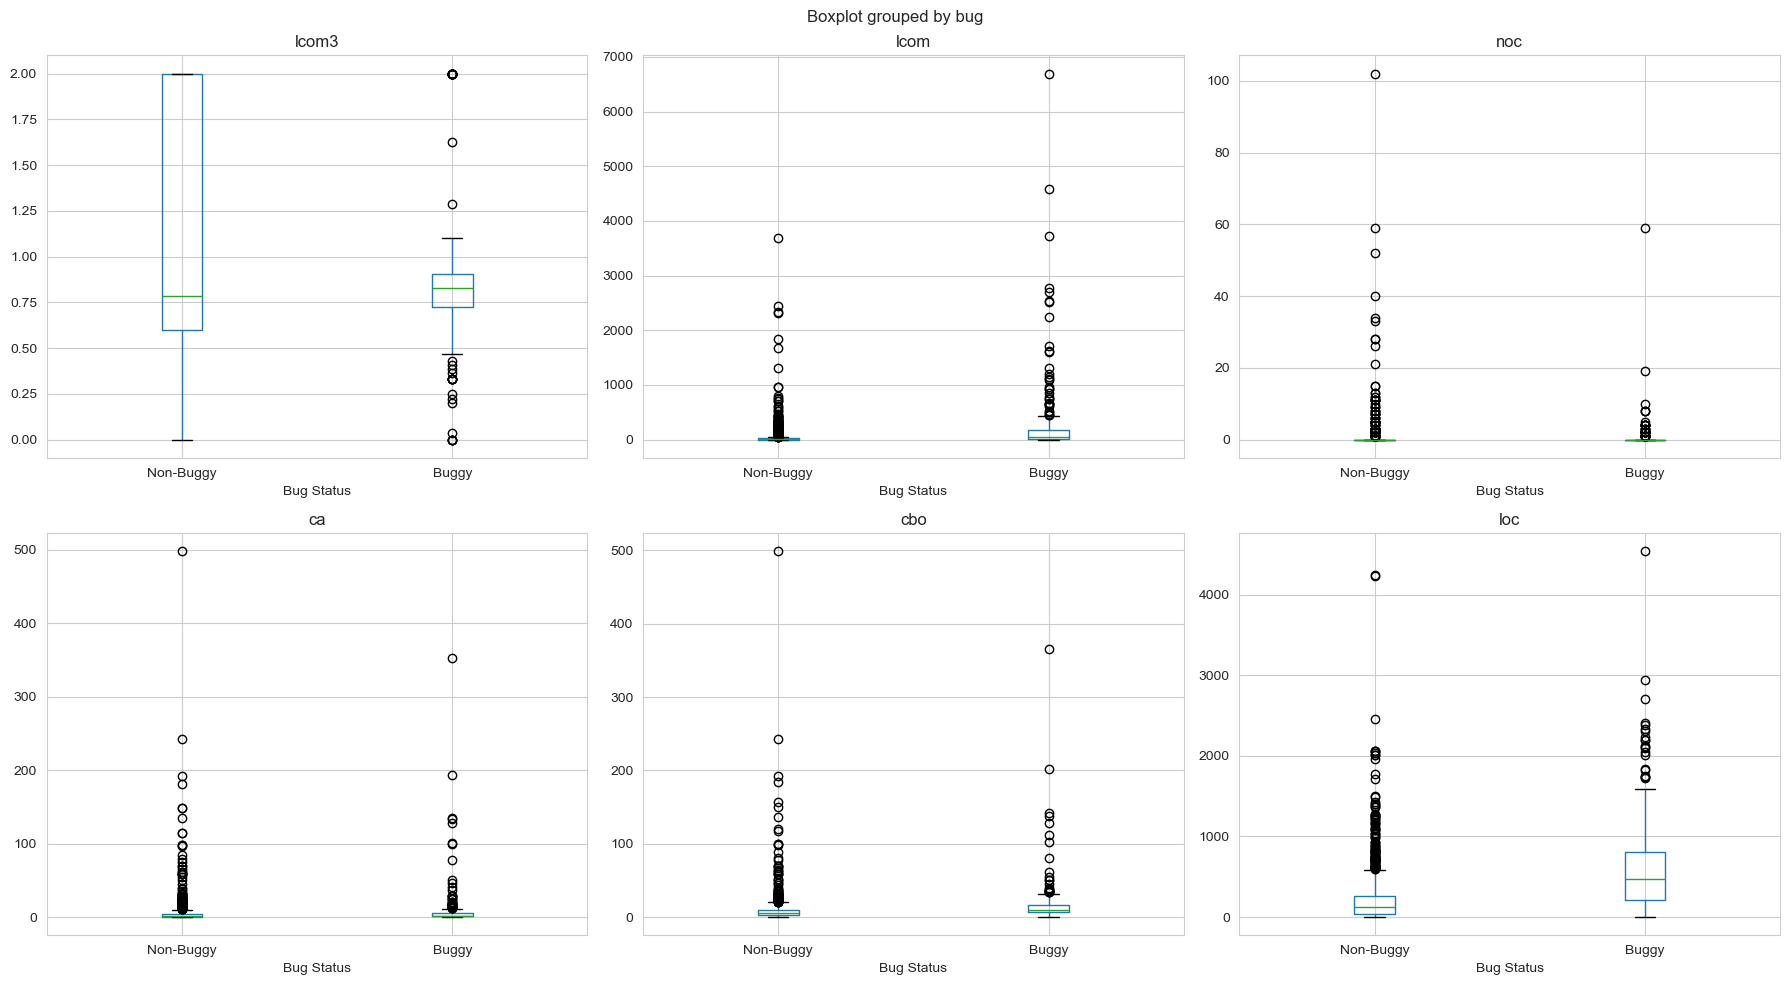


⚠️  3 columns have >10% outliers:
   ['lcom3', 'lcom', 'noc']

💡 Recommendations:
   • Consider log transformation or winsorization
   • Check if outliers are data errors or genuine extreme values
   • Robust scaling may help (RobustScaler)

5. CORRELATION ANALYSIS

Top 10 Features Correlated with Bug:
rfc       0.462703
ce        0.383064
loc       0.375369
wmc       0.362229
npm       0.310348
cam      -0.296577
moa       0.285129
max_cc    0.272900
lcom      0.216110
avg_cc    0.175557
Name: bug, dtype: float64


Multicollinearity Detection (|correlation| > 0.8):
────────────────────────────────────────────────────────────
Feature_1 Feature_2  Correlation
      cbo        ca     0.973485
      wmc       npm     0.942854
      wmc       rfc     0.884455
      dit       mfa     0.833670
    lcom3       dam    -0.832270
      wmc      lcom     0.809987
       ic       cbm     0.807986
      rfc       loc     0.806359
     lcom       npm     0.801368

⚠️  Found 9 highly correlated feat

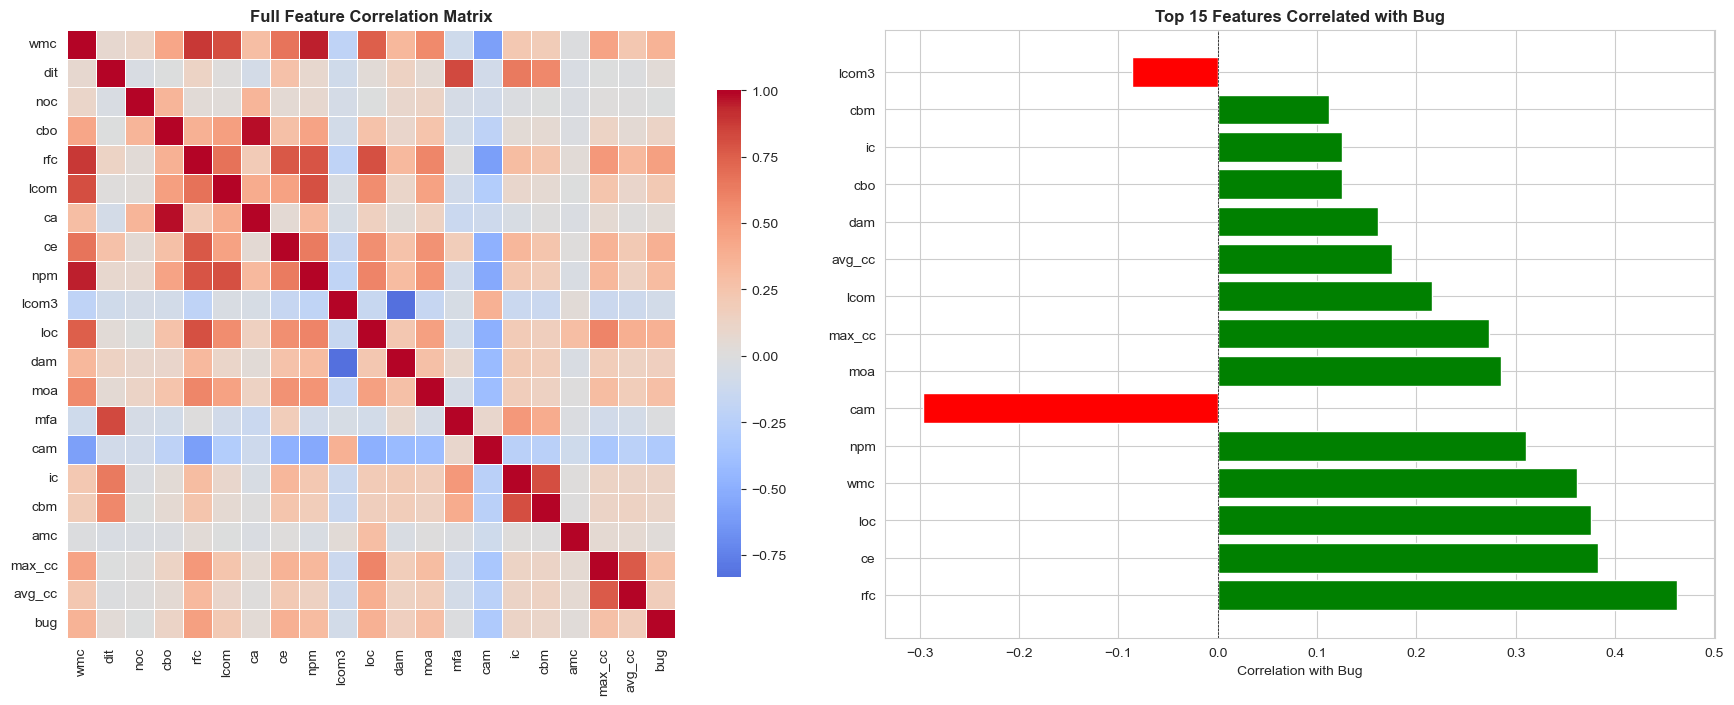


6. FEATURE DISTRIBUTION ANALYSIS

Normality Test Results (Shapiro-Wilk, p > 0.05 = Normal):
────────────────────────────────────────────────────────────
Feature  Statistic      P-Value Normal
    cam   0.941570 2.578475e-25     No
    dit   0.863521 5.134943e-36     No
  lcom3   0.836321 1.445987e-38     No
     ce   0.833049 7.530924e-39     No
 avg_cc   0.808488 7.636379e-41     No
    rfc   0.787889 2.316770e-42     No
    mfa   0.783865 1.209259e-42     No
     ic   0.739198 1.607706e-45     No
    wmc   0.715029 6.537530e-47     No
    npm   0.673316 4.257938e-49     No

📊 20/20 features are non-normal
💡 Consider transformation (log, sqrt, box-cox) for non-normal features


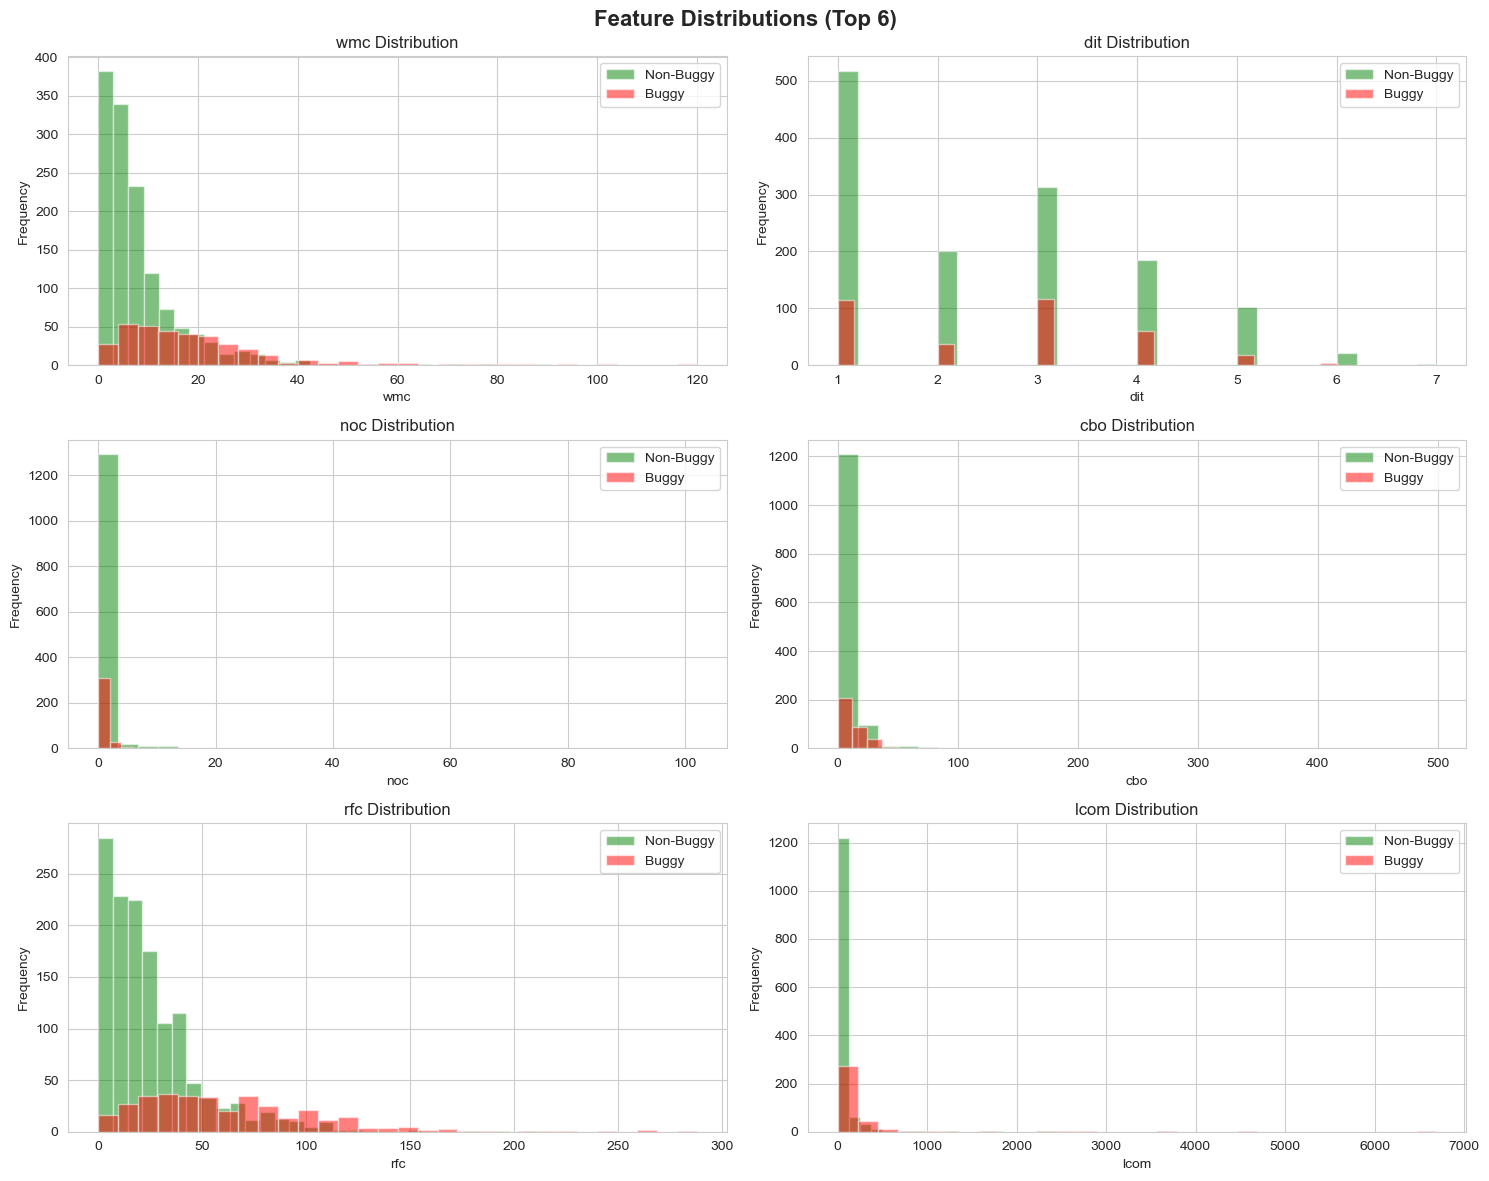


7. DIMENSIONALITY REDUCTION & VISUALIZATION

PCA Analysis:
  • Components needed for 95% variance: 12/20
  • Variance explained by first 10 components: 92.0%


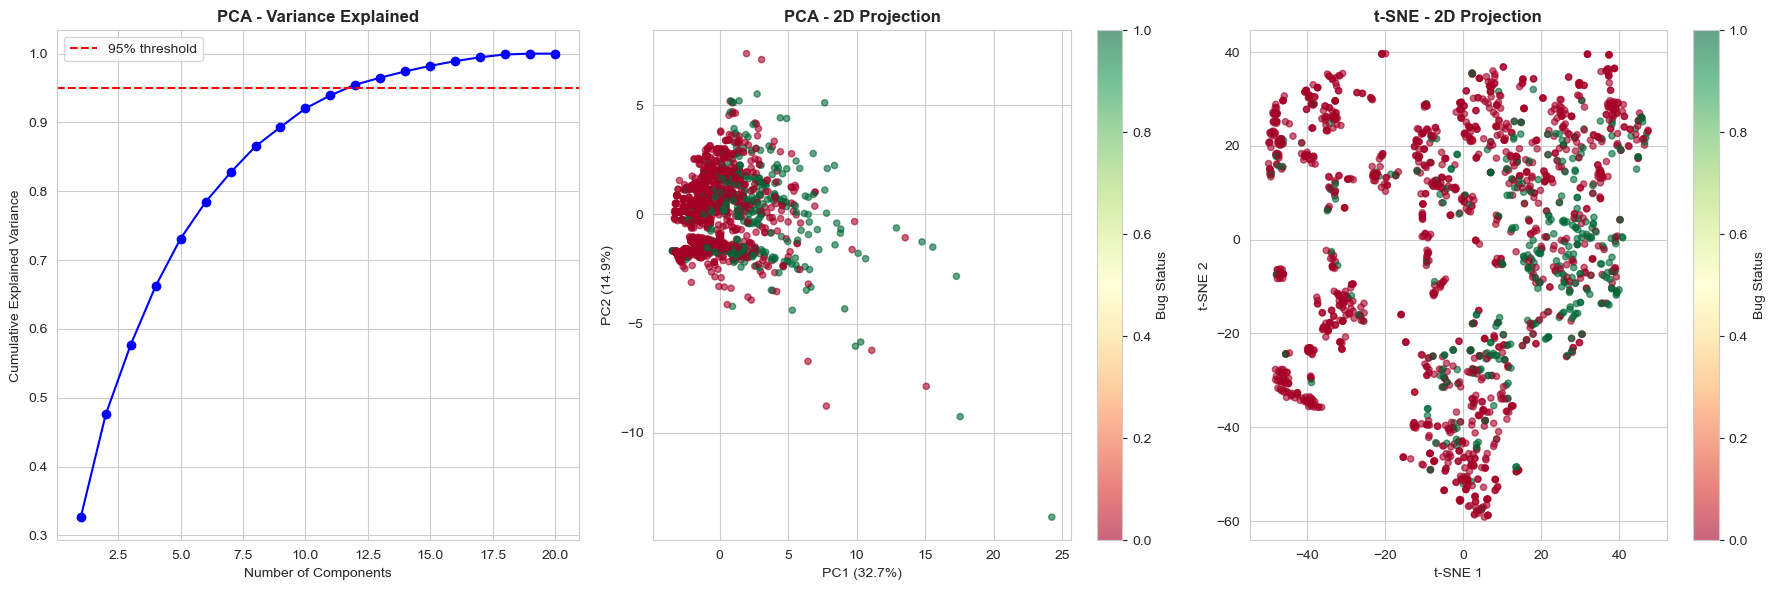


💡 Insights:
   • Data is spread across many dimensions (complex dataset)
   • Check t-SNE plot: clear clusters = good separability

8. FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
Feature  Importance
    loc    0.126934
    rfc    0.121446
    amc    0.076715
    cam    0.072604
   lcom    0.069118
     ce    0.067091
    wmc    0.057388
 avg_cc    0.054729
  lcom3    0.052989
    cbo    0.051479
    npm    0.040661
    mfa    0.038886
 max_cc    0.038633
     ca    0.030819
    dam    0.021948
    cbm    0.019143
    moa    0.019094
    dit    0.015867
     ic    0.013067
    noc    0.011388


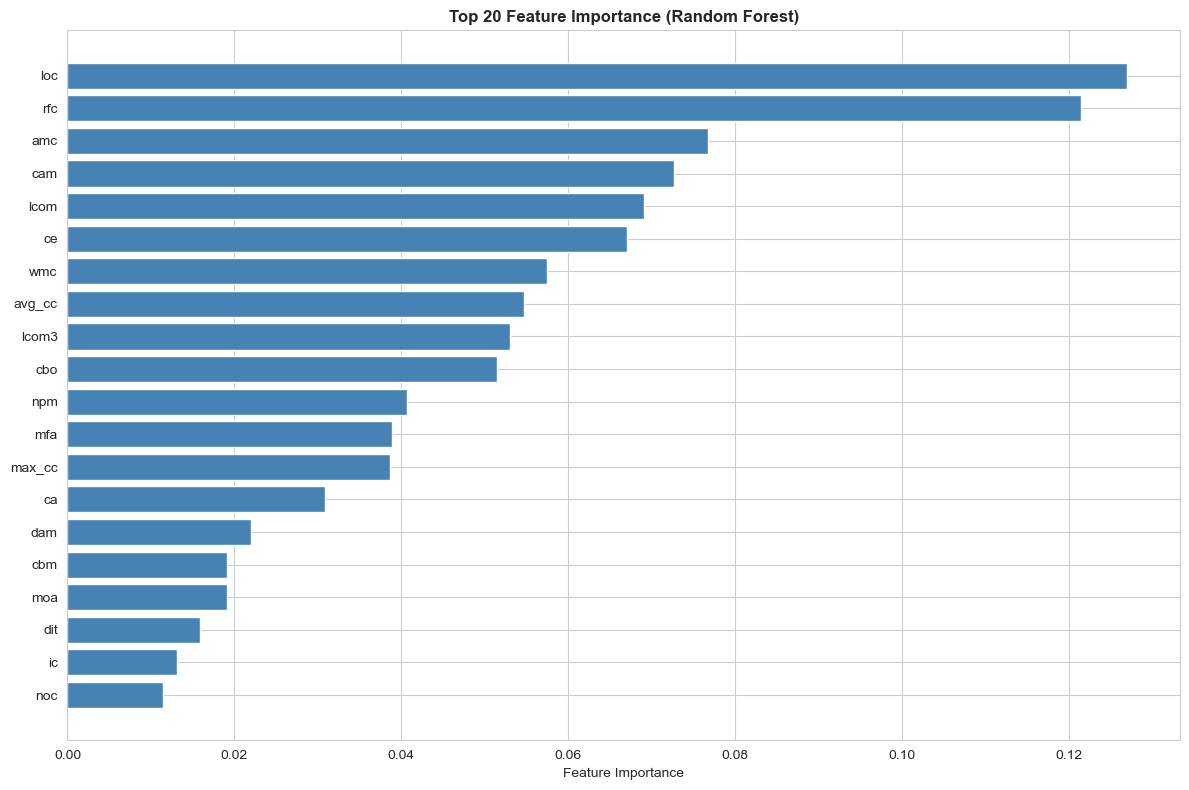


💡 Insight: Top 12 features explain 80% of importance
   Consider feature selection to reduce dimensionality

9. COMPREHENSIVE SUMMARY REPORT

DATASET OVERVIEW
File: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv
Total Rows: 1,692
Total Features: 20
Missing Data: 0 cells

────────────────────────────────────────────────────────────
CLASS DISTRIBUTION
────────────────────────────────────────────────────────────
Non-Buggy (0): 1,342 (79.3%)
Buggy (1): 350 (20.7%)
Imbalance Ratio: 3.83:1

────────────────────────────────────────────────────────────
DATA QUALITY ISSUES
────────────────────────────────────────────────────────────
✅ No missing values

────────────────────────────────────────────────────────────
RECOMMENDATIONS
────────────────────────────────────────────────────────────
• Use SMOTE or undersampling for class imbalance
• Apply feature scaling (StandardScaler or RobustScaler)
• Consider feature selection to reduce dimensionality
• Monitor for overfitting with cross-va

UnicodeEncodeError: 'charmap' codec can't encode characters in position 269-328: character maps to <undefined>

In [14]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv"
    
analyzer = BugDatasetAnalyzer(file_path, target_column='bug')
analyzer.run_complete_analysis()